# 2D Grayscale Image Fitting with gsplat (Orthographic Projection)

Fit a 2D grayscale image using 3D Gaussians rendered through the **full gsplat pipeline**
(projection → binning → compositing) with orthographic camera.

**Pipeline:**
$$\text{Gaussians} \xrightarrow{\text{ortho proj}} \text{gsplat compositing} \rightarrow \text{image} \xrightarrow{\text{MSE}} \text{loss} \rightarrow \text{update}$$

**Approach:**
- Parameterize N 3D Gaussians with means $(x_i, y_i, z_i)$, quaternions, scales, color, opacity
- $(x_i, y_i)$ correspond to image coordinates; $z_i$ is a latent depth for compositing order
- Use `gsplat.rasterization()` with `camera_model="ortho"` — no custom kernels needed
- Grayscale image is broadcast to 3-channel RGB for gsplat compatibility
- Single scalar intensity per Gaussian replicated across RGB channels

## 1. Imports and Setup

In [1]:
# !pip install zarr
# !pip install ipywidgets
# !pip install scikit-image
# !pip install pandas
# !pip install torch_dct
# !pip install zarr
# !pip install huffman
# !pip install scikit-learn
# !apt-get update && apt-get install -y ffmpeg

In [2]:
import sys, math, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import optim

import lovely_tensors as lt
lt.monkey_patch() # For better tensor printing

# import autocast and GradScaler
from torch.amp import GradScaler, autocast

# ── gsplat ────────────────────────────────────────────────────────────────
from gsplat import rasterization

# ── Data loading ─────────────────────────────────────────────────────────
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
from inct.dataset_slices import ProjectionSliceDataset

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['image.cmap'] = 'gray'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}  |  PyTorch {torch.__version__}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name()}")
print("✅ Imports ready")

Device: cuda  |  PyTorch 2.10.0+cu128
GPU: NVIDIA A100 80GB PCIe
✅ Imports ready


## 2. Load Target Image

Load the first projection from `ProjectionSliceDataset` and prepare it as a grayscale target.

✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_1_extracted
   Total TIFF files: 1711
   Darks: 10, Flats: 100, Projections: 1501
   Image dimensions: 2560 x 2160
   Use attenuation: True
✅ Loaded cached attenuation data from .tomography_cache_atten.npz
   Range: [-0.1997, 1.7837]
ProjectionSliceDataset:
  Volume shape: (1024, 1024, 50)
  Slice dimension: 2
  Slices per batch: 1
  Voxels per slice (dim=2): 1,048,576
Loading 50 projections...
  Loaded 50/50
Volume shape: (1024, 1024, 50)
Total voxels: 52,428,800
Value range: [-0.0746, 1.5249]

Target image: (1024, 1024)
Range: [0.0000, 1.0000]
GT image tensor: torch.Size([1024, 1024, 3]) on cuda:0


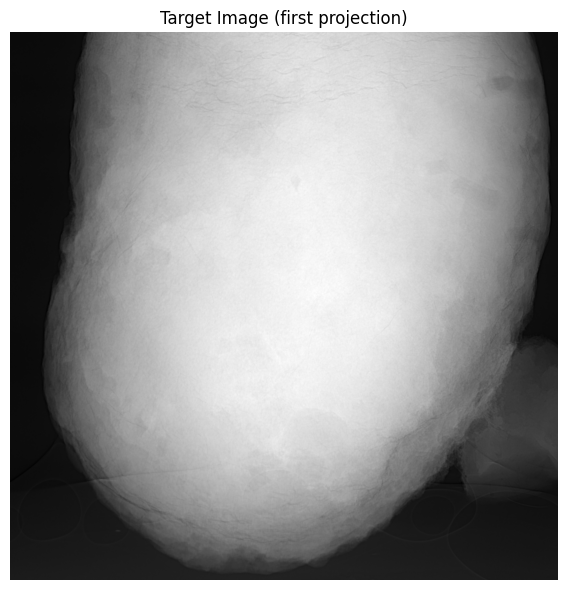

In [36]:
# ── Load dataset (same source as GSplat_Volume_Fitting notebook) ────────
DATA_PATH = Path('/myhome/data/sdate/shared/compression_paper/file_1_extracted')
NUM_PROJECTIONS = 50
TARGET_SIZE = 1024

dataset = ProjectionSliceDataset(
    folder_path=DATA_PATH,
    num_projections=NUM_PROJECTIONS,
    target_size=TARGET_SIZE,
    normalize_values=True,
    verbose=True,
    cache_volume=True,
    use_attenuation=True,
)



# Extract the first projection as the target 2D image
volume = dataset.get_full_volume()  # (H, W, D)
image_gray = volume[:, :, 0].clone()  # First projection → (H, W)

# Normalise to [0, 1]
img_min, img_max = image_gray.min(), image_gray.max()
image_gray = (image_gray - img_min) / (img_max - img_min + 1e-8)

H, W = image_gray.shape
print(f"\nTarget image: ({H}, {W})")
print(f"Range: [{image_gray.min():.4f}, {image_gray.max():.4f}]")

# Convert grayscale → RGB (H, W, 3) for gsplat
gt_image = image_gray.unsqueeze(-1).repeat(1, 1, 3).to(device)
print(f"GT image tensor: {gt_image.shape} on {gt_image.device}")

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(image_gray.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
ax.set_title('Target Image (first projection)')
ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Camera Setup (Orthographic)

Orthographic projection means no perspective distortion — rays are parallel to the z-axis.
The intrinsic matrix $K$ maps camera-space coordinates directly to pixel coordinates:

$$u = f_x \cdot x_{\text{cam}} + c_x, \quad v = f_y \cdot y_{\text{cam}} + c_y$$

We set $f_x = f_y = 1$ and $c_x = c_y = 0$, so Gaussian means in world space
are directly in pixel coordinates. The view matrix is identity, placing the camera
at the origin looking down $+z$.

In [4]:
# ── Orthographic camera ──────────────────────────────────────────────────
# K maps camera coords → pixel coords: u = fx*x + cx, v = fy*y + cy
# With fx=fy=1 and cx=cy=0, means in [0,W]×[0,H] map directly to pixels.
K = torch.tensor([
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [0.0, 0.0, 1.0],
], device=device)

# View matrix: identity (camera at origin, looking down +z)
viewmat = torch.eye(4, device=device)

print(f"Camera model: orthographic")
print(f"K (intrinsics):\n{K}")
print(f"View matrix: identity")
print(f"Image size: {W} × {H}")

Camera model: orthographic
K (intrinsics):
tensor[3, 3] n=9 x∈[0., 1.000] μ=0.333 σ=0.500 cuda:0 [[1.000, 0., 0.], [0., 1.000, 0.], [0., 0., 1.000]]
View matrix: identity
Image size: 1024 × 1024


## 4. Initialize Gaussian Parameters

Each Gaussian has:
- **means** $(x, y, z)$: $(x, y)$ in pixel space, $z$ is latent depth for compositing
- **quats** $(w, x, y, z)$: rotation quaternion
- **scales** $(s_x, s_y, s_z)$: log-space scale factors
- **rgbs**: sigmoid-space intensities (single scalar replicated to 3 channels)
- **opacities**: sigmoid-space opacity

Two initialization modes are available via `INIT_MODE`:

| Mode | Placement | Initial scale | Best for |
|------|-----------|---------------|----------|
| `'uniform'` | Regular grid (rounded to perfect square) | `INIT_SCALE_PX` | uniform / low-contrast images |
| `'intensity'` | Sampled ∝ image intensity + sub-pixel jitter | `INIT_SCALE_PX × 0.5` | images with strong bright regions; concentrates budget where signal is |


In [7]:
# ── Configuration ─────────────────────────────────────────────────────────
N_POINTS = 50_000
INIT_SCALE_PX = 3.0   # Initial Gaussian size in pixels
INIT_OPACITY = 0.3     # Initial opacity (before sigmoid)

# Initialization mode: 'uniform' (regular grid) or 'intensity' (image-driven)
#   'uniform'   – evenly-spaced grid; every region covered equally
#   'intensity' – positions sampled proportional to image intensity;
#                 bright regions receive more Gaussians, dark regions fewer
INIT_MODE = 'intensity'

torch.manual_seed(42)

# ── Means ─────────────────────────────────────────────────────────────────
if INIT_MODE == 'uniform':
    # Regular grid + tiny jitter – original behaviour
    n_side = int(math.ceil(math.sqrt(N_POINTS)))
    N_POINTS = n_side * n_side          # round up to perfect square
    xs = torch.linspace(0, W, n_side, device=device)
    ys = torch.linspace(0, H, n_side, device=device)
    grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')
    means_xy = torch.stack([grid_x.reshape(-1), grid_y.reshape(-1)], dim=-1)  # [N, 2]

elif INIT_MODE == 'intensity':
    # Sample pixel locations proportional to image intensity.
    # Pixels with higher intensity receive proportionally more Gaussians.
    # A small floor (eps) ensures every pixel has non-zero probability so
    # dark regions still get some coverage.
    img_flat = image_gray.to(device).reshape(-1).float()   # [H*W]
    eps = 1e-3
    weights = (img_flat + eps)                              # strictly positive
    weights = weights / weights.sum()                       # normalise to prob

    # Sample N_POINTS pixel indices with replacement
    pixel_indices = torch.multinomial(weights, N_POINTS, replacement=True)  # [N]
    # Convert flat index → (x, y) pixel coordinates
    px_init = (pixel_indices % W).float()                  # column → x
    py_init = (pixel_indices // W).float()                 # row    → y

    # Add sub-pixel jitter so co-located samples spread within the pixel
    px_init = px_init + torch.rand(N_POINTS, device=device) - 0.5
    py_init = py_init + torch.rand(N_POINTS, device=device) - 0.5
    px_init = px_init.clamp(0, W - 1e-3)
    py_init = py_init.clamp(0, H - 1e-3)

    means_xy = torch.stack([px_init, py_init], dim=-1)     # [N, 2]

else:
    raise ValueError(f"Unknown INIT_MODE '{INIT_MODE}'. Choose 'uniform' or 'intensity'.")

# z: small positive depth (must be > near_plane for visibility)
means_z = 1.0 + 0.1 * torch.randn(N_POINTS, 1, device=device)
means = torch.cat([means_xy, means_z], dim=-1)             # [N, 3]

# ── Scales: log-space, initialised to ~INIT_SCALE_PX pixels ─────────────
if INIT_MODE == 'intensity':
    # In intensity mode many Gaussians cluster in bright regions, so start
    # them smaller to reduce initial over-coverage of those areas.
    log_scales = torch.full((N_POINTS, 3), math.log(INIT_SCALE_PX ), device=device)
else:
    log_scales = torch.full((N_POINTS, 3), math.log(INIT_SCALE_PX), device=device)
# z-scale small: depth extent is invisible in ortho projection
log_scales[:, 2] = math.log(0.5)

# ── Quaternions: identity rotation ───────────────────────────────────────
quats = torch.zeros(N_POINTS, 4, device=device)
quats[:, 0] = 1.0   # w=1  →  no rotation

# ── Colors: sample from target image at each Gaussian's (x, y) ──────────
px_idx = means[:, 0].long().clamp(0, W - 1)
py_idx = means[:, 1].long().clamp(0, H - 1)
sampled_intensity = image_gray.to(device)[py_idx, px_idx]  # [N]

# For intensity init, initialise color directly from the sampled value.
# For uniform init this was already done the same way, kept for consistency.
rgbs = torch.logit(sampled_intensity.clamp(0.01, 0.99)).unsqueeze(-1).repeat(1, 3)  # [N, 3]

# ── Opacities: moderate initial value ────────────────────────────────────
opacities = torch.logit(torch.full((N_POINTS,), INIT_OPACITY, device=device))  # [N]

# ── Enable gradients ──────────────────────────────────────────────────────
means.requires_grad_(True)
log_scales.requires_grad_(True)
quats.requires_grad_(True)
rgbs.requires_grad_(True)
opacities.requires_grad_(True)

n_params = means.numel() + log_scales.numel() + quats.numel() + rgbs.numel() + opacities.numel()
print(f"Init mode:  {INIT_MODE}")
print(f"Gaussians:  {N_POINTS:,}")
print(f"Parameters: {n_params:,} ({n_params * 4 / 1e6:.2f} MB)")
print(f"  means:      {means.shape}")
print(f"  log_scales: {log_scales.shape}")
print(f"  quats:      {quats.shape}")
print(f"  rgbs:       {rgbs.shape}")
print(f"  opacities:  {opacities.shape}")

if INIT_MODE == 'intensity':
    # Quick density check
    img_flat_np = image_gray.cpu().numpy().reshape(-1)
    bright_frac = float((img_flat_np > 0.5).mean())
    bright_gaussians = int((sampled_intensity.cpu().numpy() > 0.5).sum())
    print(f"\nIntensity-init stats:")
    print(f"  Bright pixels  (>0.5): {bright_frac*100:.1f}% of image")
    print(f"  Bright Gaussians(>0.5): {bright_gaussians/N_POINTS*100:.1f}% of N_POINTS")


Init mode:  intensity
Gaussians:  50,000
Parameters: 700,000 (2.80 MB)
  means:      torch.Size([50000, 3])
  log_scales: torch.Size([50000, 3])
  quats:      torch.Size([50000, 4])
  rgbs:       torch.Size([50000, 3])
  opacities:  torch.Size([50000])

Intensity-init stats:
  Bright pixels  (>0.5): 59.0% of image
  Bright Gaussians(>0.5): 84.4% of N_POINTS


## 5. Rendering Function

A thin wrapper around `gsplat.rasterization()` that applies activations
and calls the full pipeline (projection → tile binning → compositing).

Test render: torch.Size([1024, 1024, 3]), range [0.0000, 0.9402]
Alpha: torch.Size([1024, 1024, 1]), range [0.0000, 0.9840]


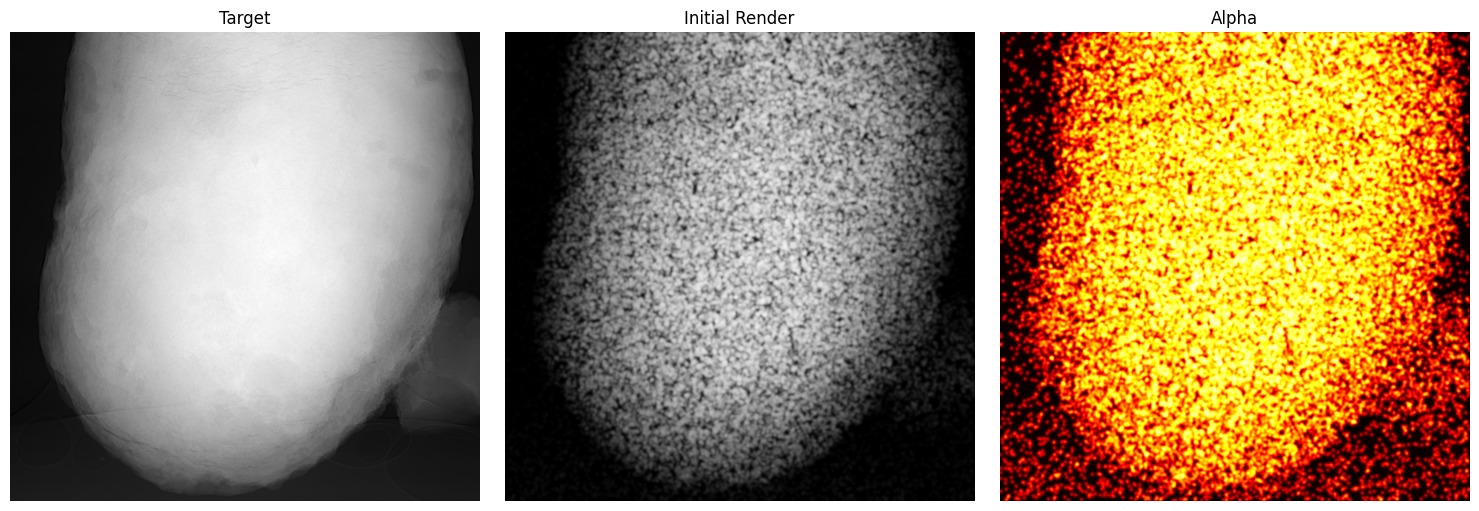

In [8]:
def render(
    means: torch.Tensor,
    log_scales: torch.Tensor,
    quats: torch.Tensor,
    rgbs: torch.Tensor,
    opacities: torch.Tensor,
    viewmat: torch.Tensor,
    K: torch.Tensor,
    W: int,
    H: int,
    near_plane: float = 0.01,
    far_plane: float = 100.0,
) -> torch.Tensor:
    """Render image via gsplat's full rasterization pipeline (orthographic).
    
    Returns:
        rendered: (H, W, 3) rendered RGB image
    """
    # Apply activations
    scales = torch.exp(log_scales)                     # [N, 3]
    colors = torch.sigmoid(rgbs)                       # [N, 3]
    opac = torch.sigmoid(opacities)                    # [N]
    q = quats / quats.norm(dim=-1, keepdim=True)       # [N, 4]
    
    # Full gsplat pipeline: projection → binning → compositing
    renders, alphas, info = rasterization(
        means=means,              # [N, 3]
        quats=q,                  # [N, 4]
        scales=scales,            # [N, 3]
        opacities=opac,           # [N]
        colors=colors,            # [N, 3]
        viewmats=viewmat[None],   # [1, 4, 4]
        Ks=K[None],              # [1, 3, 3]
        width=W,
        height=H,
        near_plane=near_plane,
        far_plane=far_plane,
        packed=False,
        camera_model="ortho",
    )
    
    rendered = renders[0]  # [H, W, 3]
    return rendered, alphas[0], info


# Quick test render
with torch.no_grad():
    test_render, test_alpha, _ = render(means, log_scales, quats, rgbs, opacities, viewmat, K, W, H)
    print(f"Test render: {test_render.shape}, range [{test_render.min():.4f}, {test_render.max():.4f}]")
    print(f"Alpha: {test_alpha.shape}, range [{test_alpha.min():.4f}, {test_alpha.max():.4f}]")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gt_image[:, :, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Target')
axes[0].axis('off')
axes[1].imshow(test_render[:, :, 0].detach().cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Initial Render')
axes[1].axis('off')
axes[2].imshow(test_alpha[:, :, 0].detach().cpu().numpy(), cmap='hot', vmin=0, vmax=1)
axes[2].set_title('Alpha')
axes[2].axis('off')
plt.tight_layout()
plt.show()

## 6. Training Loop

Optimise all Gaussian parameters with Adam, using MSE loss between rendered and target image.
The full gsplat pipeline runs each iteration: projection → tile binning → compositing → loss → backprop.

**Adaptive control** is interleaved inside the loop every `DENSIFY_INTERVAL` iterations (between `DENSIFY_FROM` and `DENSIFY_UNTIL`):
- **Pruning** — remove Gaussians whose sigmoid-opacity falls below `PRUNE_OPACITY_THRESH`
- **Densification** — split Gaussians whose max xy-scale exceeds `SPLIT_SCALE_THRESH` into two children with half the scale
- The optimizer is rebuilt after each event to track the new tensor references
- Learning rates are halved once training passes the halfway point


In [9]:
# ── Training configuration ───────────────────────────────────────────────
USE_FP16       = True
NUM_ITERATIONS = 15000
LOG_INTERVAL   = 100

# Separate learning rates for better convergence
LR_MEANS     = 1e-3
LR_SCALES    = 5e-3
LR_QUATS     = 1e-3
LR_RGBS      = 1e-2
LR_OPACITIES = 5e-2

# ── Adaptive control: pruning + densification ────────────────────────────
DENSIFY_FROM      = 500    # start events at this iteration
DENSIFY_INTERVAL  = 500    # prune + densify every N iterations
DENSIFY_UNTIL     = 12000  # stop events well before the end (avoids late disruption)
PRUNE_OPACITY_THRESH = 0.005   # sigmoid(opacity) below this → prune
SPLIT_SCALE_THRESH   = 10.0   # max xy-scale (pixels) above this → split

def make_optimizer(lr_scale: float = 1.0):
    """Build a fresh Adam optimizer; call after any tensor-reference change."""
    return optim.Adam([
        {'params': [means],      'lr': LR_MEANS     * lr_scale, 'name': 'means'},
        {'params': [log_scales], 'lr': LR_SCALES    * lr_scale, 'name': 'scales'},
        {'params': [quats],      'lr': LR_QUATS     * lr_scale, 'name': 'quats'},
        {'params': [rgbs],       'lr': LR_RGBS      * lr_scale, 'name': 'rgbs'},
        {'params': [opacities],  'lr': LR_OPACITIES * lr_scale, 'name': 'opacities'},
    ])

optimizer    = make_optimizer()
scaler       = GradScaler(enabled=USE_FP16)
mse_loss_fn  = torch.nn.MSELoss()

print(f"Training config:")
print(f"  Iterations:      {NUM_ITERATIONS}")
print(f"  Precision:       {'fp16 (mixed)' if USE_FP16 else 'fp32'}")
print(f"  LR means={LR_MEANS}, scales={LR_SCALES}, quats={LR_QUATS}, rgbs={LR_RGBS}, opac={LR_OPACITIES}")
print(f"  Gaussians:       {N_POINTS:,}")
print(f"  Densify every:   {DENSIFY_INTERVAL} iters  [{DENSIFY_FROM} – {DENSIFY_UNTIL}]")
print(f"  Prune  thresh:   opacity < {PRUNE_OPACITY_THRESH}")
print(f"  Split  thresh:   scale   > {SPLIT_SCALE_THRESH} px")


Training config:
  Iterations:      15000
  Precision:       fp16 (mixed)
  LR means=0.001, scales=0.005, quats=0.001, rgbs=0.01, opac=0.05
  Gaussians:       50,000
  Densify every:   500 iters  [500 – 12000]
  Prune  thresh:   opacity < 0.005
  Split  thresh:   scale   > 10.0 px


In [10]:
# ── Unified training loop with adaptive pruning + densification ──────────
loss_history  = []
psnr_history  = []
densify_iters = []   # records which iterations had a densify event
times_fwd     = []
times_bwd     = []

t_start = time.time()
print("Starting training with adaptive pruning + densification…")
print("=" * 65)

for iteration in range(NUM_ITERATIONS):

    # ── Forward ────────────────────────────────────────────────────────
    t0 = time.time()
    with autocast(device_type='cuda', dtype=torch.float16, enabled=USE_FP16):
        rendered, alpha, info = render(
            means, log_scales, quats, rgbs, opacities,
            viewmat, K, W, H,
        )
        loss = mse_loss_fn(rendered, gt_image)
    torch.cuda.synchronize()
    t_fwd = time.time() - t0

    # ── Backward + update ─────────────────────────────────────────────
    optimizer.zero_grad()
    t0 = time.time()
    scaler.scale(loss).backward()
    torch.cuda.synchronize()
    t_bwd = time.time() - t0
    scaler.step(optimizer)
    scaler.update()

    # ── Enforce grayscale constraint: keep RGB channels equal ─────────
    with torch.no_grad():
        rgb_mean = rgbs.data.mean(dim=-1, keepdim=True)
        rgbs.data.copy_(rgb_mean.expand_as(rgbs))

    # ── Record metrics ────────────────────────────────────────────────
    loss_val = loss.item()
    psnr     = -10 * math.log10(loss_val + 1e-10)
    loss_history.append(loss_val)
    psnr_history.append(psnr)
    times_fwd.append(t_fwd)
    times_bwd.append(t_bwd)

    if iteration % LOG_INTERVAL == 0 or iteration == NUM_ITERATIONS - 1:
        print(f"[{iteration:5d}/{NUM_ITERATIONS}]  "
              f"loss={loss_val:.6f}  PSNR={psnr:.2f} dB  N={means.shape[0]:,}  "
              f"fwd={t_fwd*1000:.1f}ms  bwd={t_bwd*1000:.1f}ms")

    # ── Adaptive control: pruning + densification ─────────────────────
    if (DENSIFY_FROM <= iteration < DENSIFY_UNTIL
            and iteration % DENSIFY_INTERVAL == 0
            and iteration > 0):

        n_before = means.shape[0]
        with torch.no_grad():

            # ── Prune low-opacity Gaussians ────────────────────────────
            opac_vals = torch.sigmoid(opacities)
            keep_mask = opac_vals > PRUNE_OPACITY_THRESH
            n_pruned  = n_before - keep_mask.sum().item()

            if n_pruned > 0:
                means      = means.data[keep_mask].clone().requires_grad_(True)
                log_scales = log_scales.data[keep_mask].clone().requires_grad_(True)
                quats      = quats.data[keep_mask].clone().requires_grad_(True)
                rgbs       = rgbs.data[keep_mask].clone().requires_grad_(True)
                opacities  = opacities.data[keep_mask].clone().requires_grad_(True)

            # ── Split over-large Gaussians ─────────────────────────────
            scales_now = torch.exp(log_scales)
            split_mask = scales_now[:, :2].max(dim=1).values > SPLIT_SCALE_THRESH
            n_split    = split_mask.sum().item()

            if n_split > 0:
                parent_means  = means.data[split_mask]
                parent_scales = log_scales.data[split_mask]
                parent_quats  = quats.data[split_mask]
                parent_rgbs   = rgbs.data[split_mask]
                parent_opac   = opacities.data[split_mask]

                offset    = 0.5 * torch.exp(parent_scales[:, :2])
                offset_3d = torch.zeros_like(parent_means)
                offset_3d[:, :2] = offset

                child1_means  = parent_means + offset_3d
                child2_means  = parent_means - offset_3d
                child_scales  = parent_scales - math.log(2.0)   # halve the scale

                keep       = ~split_mask
                means      = torch.cat([means.data[keep],
                                        child1_means, child2_means],             dim=0).requires_grad_(True)
                log_scales = torch.cat([log_scales.data[keep],
                                        child_scales, child_scales.clone()],     dim=0).requires_grad_(True)
                quats      = torch.cat([quats.data[keep],
                                        parent_quats, parent_quats.clone()],     dim=0).requires_grad_(True)
                rgbs       = torch.cat([rgbs.data[keep],
                                        parent_rgbs, parent_rgbs.clone()],       dim=0).requires_grad_(True)
                opacities  = torch.cat([opacities.data[keep],
                                        parent_opac, parent_opac.clone()],       dim=0).requires_grad_(True)

            N_POINTS = means.shape[0]

        # Rebuild optimizer — required whenever tensor references change
        lr_scale  = 0.5 if iteration > NUM_ITERATIONS // 2 else 1.0
        optimizer = make_optimizer(lr_scale)
        scaler    = GradScaler(enabled=USE_FP16)

        densify_iters.append(iteration)
        print(f"  ↳ [densify @ {iteration}]  pruned={n_pruned}  split={n_split}  "
              f"N={N_POINTS:,}  lr_scale={lr_scale}")

elapsed = time.time() - t_start
avg_fwd = np.mean(times_fwd) * 1000
avg_bwd = np.mean(times_bwd) * 1000

print(f"\n✅ Training complete in {elapsed:.1f}s")
print(f"   Final loss:      {loss_history[-1]:.6f}")
print(f"   Final PSNR:      {psnr_history[-1]:.2f} dB")
print(f"   Gaussians:       {means.shape[0]:,}")
print(f"   Densify events:  {len(densify_iters)}  @ iters {densify_iters}")
print(f"   Avg forward:     {avg_fwd:.2f} ms/iter")
print(f"   Avg backward:    {avg_bwd:.2f} ms/iter")
print(f"   Throughput:      {NUM_ITERATIONS / elapsed:.1f} iter/s")

# ── Backward-compat aliases used by downstream cells ─────────────────────
loss_history_p2 = []
psnr_history_p2 = []
elapsed_p2      = 0.0
all_losses      = loss_history
all_psnrs       = psnr_history


Starting training with adaptive pruning + densification…
[    0/15000]  loss=0.049361  PSNR=13.07 dB  N=50,000  fwd=13.3ms  bwd=163.6ms
[  100/15000]  loss=0.000566  PSNR=32.47 dB  N=50,000  fwd=1.0ms  bwd=1.3ms
[  200/15000]  loss=0.000188  PSNR=37.25 dB  N=50,000  fwd=1.0ms  bwd=1.4ms
[  300/15000]  loss=0.000122  PSNR=39.15 dB  N=50,000  fwd=0.8ms  bwd=1.2ms
[  400/15000]  loss=0.000098  PSNR=40.10 dB  N=50,000  fwd=1.0ms  bwd=1.5ms
[  500/15000]  loss=0.000085  PSNR=40.69 dB  N=50,000  fwd=1.0ms  bwd=1.4ms
  ↳ [densify @ 500]  pruned=0  split=242  N=50,242  lr_scale=1.0
[  600/15000]  loss=0.000061  PSNR=42.14 dB  N=50,242  fwd=0.8ms  bwd=1.4ms
[  700/15000]  loss=0.000054  PSNR=42.67 dB  N=50,242  fwd=0.8ms  bwd=1.4ms
[  800/15000]  loss=0.000050  PSNR=43.01 dB  N=50,242  fwd=1.0ms  bwd=1.6ms
[  900/15000]  loss=0.000047  PSNR=43.26 dB  N=50,242  fwd=1.0ms  bwd=2.9ms
[ 1000/15000]  loss=0.000045  PSNR=43.46 dB  N=50,242  fwd=1.2ms  bwd=1.7ms
  ↳ [densify @ 1000]  pruned=0  split=7

## 7. Visualization

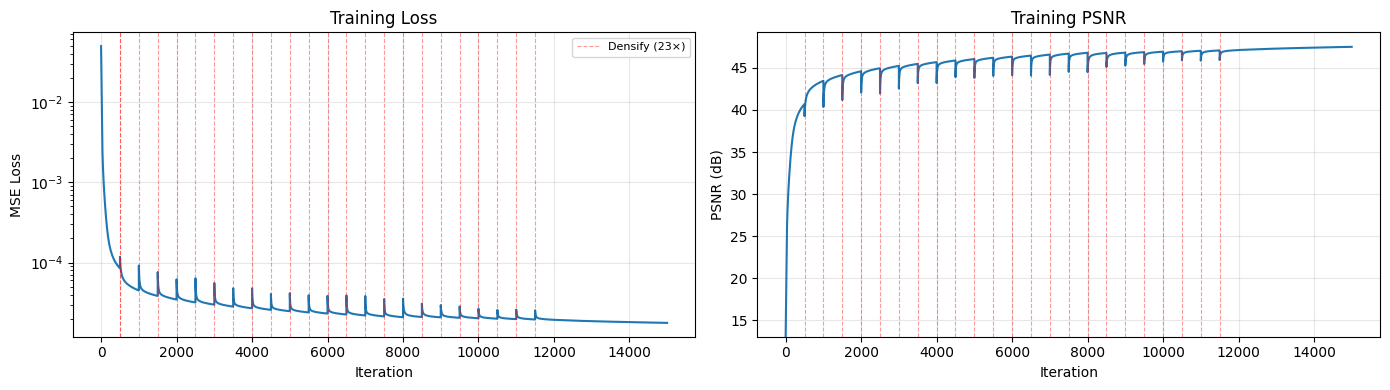

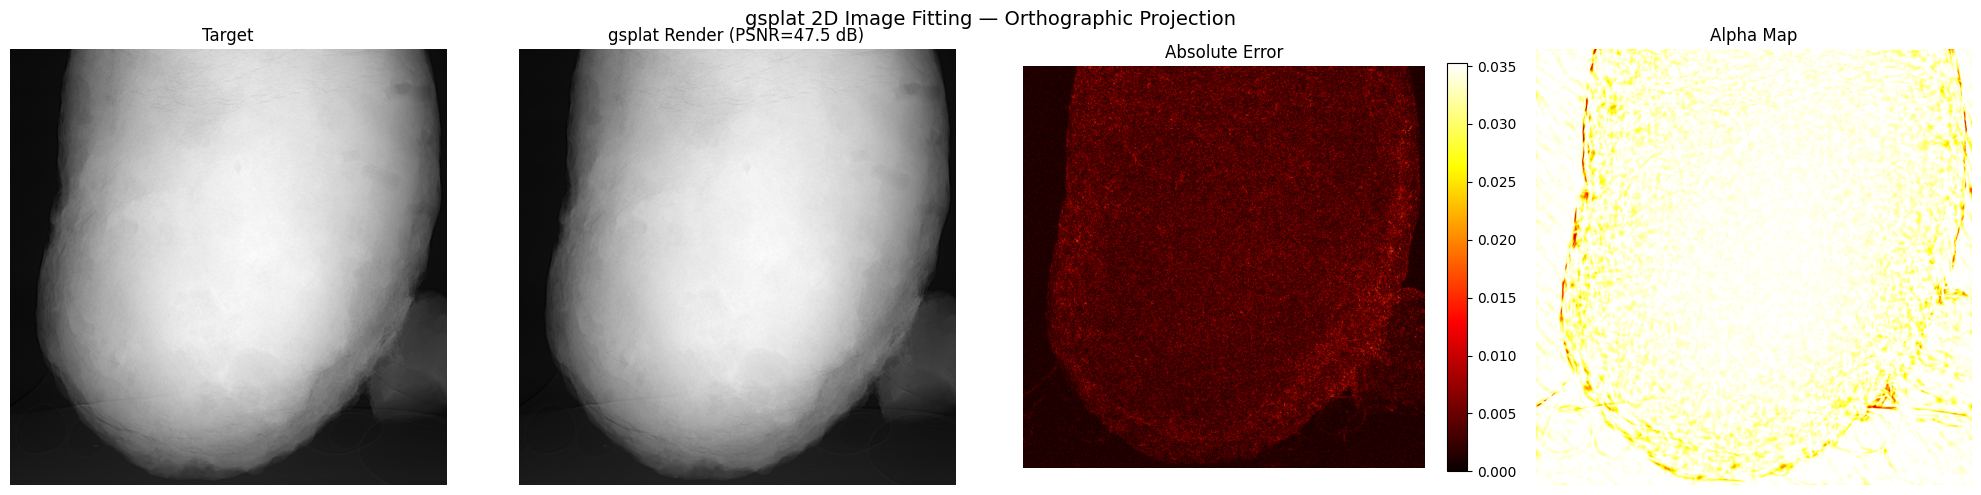

In [11]:
# ── Final render ──────────────────────────────────────────────────────────
with torch.no_grad():
    final_render, final_alpha, _ = render(
        means, log_scales, quats, rgbs, opacities,
        viewmat, K, W, H,
    )

final_np = final_render[:, :, 0].cpu().numpy()
target_np = gt_image[:, :, 0].cpu().numpy()
alpha_np  = final_alpha[:, :, 0].cpu().numpy()
error_np  = np.abs(final_np - target_np)

# ── Loss & PSNR curves ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].semilogy(loss_history)
for di in densify_iters:
    axes[0].axvline(x=di, color='r', linestyle='--', alpha=0.4, linewidth=0.8)
if densify_iters:
    axes[0].axvline(x=densify_iters[0], color='r', linestyle='--', alpha=0.4,
                    linewidth=0.8, label=f'Densify ({len(densify_iters)}×)')
    axes[0].legend(fontsize=8)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(psnr_history)
for di in densify_iters:
    axes[1].axvline(x=di, color='r', linestyle='--', alpha=0.4, linewidth=0.8)
axes[1].set_ylim(bottom=min(psnr_history[:100]) if psnr_history else 0)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('PSNR (dB)')
axes[1].set_title('Training PSNR')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Side-by-side comparison ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(target_np, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Target')
axes[0].axis('off')

axes[1].imshow(np.clip(final_np, 0, 1), cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'gsplat Render (PSNR={psnr_history[-1]:.1f} dB)')
axes[1].axis('off')

im = axes[2].imshow(error_np, cmap='hot')
axes[2].set_title('Absolute Error')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)

axes[3].imshow(alpha_np, cmap='hot', vmin=0, vmax=1)
axes[3].set_title('Alpha Map')
axes[3].axis('off')

plt.suptitle('gsplat 2D Image Fitting — Orthographic Projection', fontsize=14)
plt.tight_layout()
plt.show()


## 8. Metrics & Compression Summary

In [37]:
# plt.figure(figsize=(20, 20))
# plt.imshow(error_np, cmap='hot')

In [13]:
from skimage.metrics import structural_similarity as ssim

final_mse = np.mean((np.clip(final_np, 0, 1) - target_np) ** 2)
final_psnr = -10 * np.log10(final_mse + 1e-10)
final_ssim = ssim(target_np, np.clip(final_np, 0, 1), data_range=1.0)

# Model size: each Gaussian has 3 (mean) + 3 (scale) + 4 (quat) + 1 (rgb scalar) + 1 (opacity) = 12 params
# Using grayscale constraint: 12 params per Gaussian
n_active = means.shape[0]
params_per_gaussian = 3 + 3 + 4 + 1 + 1  # mean + scale + quat + intensity + opacity
bytes_per_param = 2 if USE_FP16 else 4  # FP16 = 2 bytes, FP32 = 4 bytes
model_bytes = n_active * params_per_gaussian * bytes_per_param
original_bytes = H * W * 2  # int16 original
compression_ratio = original_bytes / model_bytes

print(f"{'='*50}")
print(f"IMAGE FITTING METRICS (gsplat ortho)")
print(f"{'='*50}")
print(f"  MSE:               {final_mse:.6f}")
print(f"  PSNR:              {final_psnr:.2f} dB")
print(f"  SSIM:              {final_ssim:.4f}")
print(f"  Gaussians:         {n_active:,}")
print(f"  Params/Gaussian:   {params_per_gaussian}")
print(f"  Model size:        {model_bytes / 1e6:.2f} MB")
print(f"  Original size:     {original_bytes / 1e6:.2f} MB (int16)")
print(f"  Compression ratio: {compression_ratio:.2f}×")
print(f"  Training time:     {elapsed:.1f}s ({NUM_ITERATIONS / elapsed:.0f} iter/s)")

IMAGE FITTING METRICS (gsplat ortho)
  MSE:               0.000018
  PSNR:              47.50 dB
  SSIM:              0.9838
  Gaussians:         62,327
  Params/Gaussian:   12
  Model size:        2.99 MB
  Original size:     2.10 MB (int16)
  Compression ratio: 0.70×
  Training time:     63.4s (237 iter/s)


## 8b. Parameter Redundancy Analysis (3D Gaussians for 2D Fitting)

For orthographic 2D image fitting, several parameters of the full 3D Gaussian representation are redundant.
This cell quantifies exactly which ones and computes the storage savings.

In [38]:
N = means.shape[0]  # current number of Gaussians (post phase-2 if run)

# ─────────────────────────────────────────────────────────────────────────────
# Parameter inventory
# Each row: (name, stored_floats, needed_floats, redundant_floats, reason)
# ─────────────────────────────────────────────────────────────────────────────
param_table = [
    # name                     stored  needed  redundant  reason
    ("means (x,y,z)",               3, 3, 0,
     "x,y = pixel position; z = depth for alpha-composition sort — all needed"),

    ("log_scales (sx,sy,sz)",       3, 2, 1,
     "sz is invisible to the rendered image: for ortho projection Σ_2D is the "
     "upper-left 2×2 block of R·diag(sx²,sy²,sz²)·Rᵀ; sz only enters via "
     "R[i,2] which are the out-of-plane tilt rows — zero for pure z-rotation"),

    ("quats (w,x,y,z)",             4, 2, 2,
     "Only in-plane rotation (1 DOF, rotation around z-axis) affects the "
     "projected 2-D Gaussian shape. Can be stored as (cos θ, sin θ) instead "
     "of a full quaternion; qx, qy encode out-of-plane tilts that are "
     "irrelevant when sz ≈ 0"),

    ("rgbs (r,g,b)",                3, 1, 2,
     "Grayscale image: training loop enforces r=g=b every step. "
     "Two channels are identical copies of the first."),

    ("opacities",                   1, 1, 0,
     "Fully needed — controls blend weight in compositing"),
]

# ── Print table ──────────────────────────────────────────────────────────────
print("=" * 90)
print("  PARAMETER REDUNDANCY ANALYSIS — 3D Gaussians for 2D Orthographic Fitting")
print("=" * 90)
print(f"  {'Parameter':<26} {'Stored':>6} {'Needed':>6} {'Redundant':>9}")
print("-" * 90)

total_stored = total_needed = total_redundant = 0
for name, stored, needed, redundant, note in param_table:
    print(f"  {name:<26} {stored:>6} {needed:>6} {redundant:>9}")
    total_stored    += stored
    total_needed    += needed
    total_redundant += redundant

print("-" * 90)
print(f"  {'TOTAL per Gaussian':<26} {total_stored:>6} {total_needed:>6} {total_redundant:>9}")
print("=" * 90)

# ── Detailed notes ───────────────────────────────────────────────────────────
print()
print("Redundant parameters explained:")
for name, stored, needed, redundant, note in param_table:
    if redundant > 0:
        print(f"\n  [{name}]  {stored} stored → {needed} needed  ({redundant} redundant)")
        words = note.split()
        line, col = "    ", 4
        for w in words:
            if col + len(w) + 1 > 84:
                print(line); line = "    " + w + " "; col = 4 + len(w) + 1
            else:
                line += w + " "; col += len(w) + 1
        print(line.rstrip())

# ── Storage savings ──────────────────────────────────────────────────────────
bytes_per_float = 4  # float32

current_bytes   = N * total_stored    * bytes_per_float
minimal_bytes   = N * total_needed    * bytes_per_float
saved_bytes     = N * total_redundant * bytes_per_float
saving_pct      = 100.0 * total_redundant / total_stored

print()
print("=" * 60)
print("  STORAGE SAVINGS")
print("=" * 60)
print(f"  Active Gaussians          : {N:>10,}")
print(f"  Floats/Gaussian (current) : {total_stored:>10}")
print(f"  Floats/Gaussian (minimal) : {total_needed:>10}")
print(f"  Redundant floats/Gaussian : {total_redundant:>10}")
print()
print(f"  Current storage  : {current_bytes/1e6:>8.2f} MB  ({current_bytes:,} bytes)")
print(f"  Minimal storage  : {minimal_bytes/1e6:>8.2f} MB  ({minimal_bytes:,} bytes)")
print(f"  Savings          : {saved_bytes/1e6:>8.2f} MB  ({saved_bytes:,} bytes)")
print(f"  Reduction        : {saving_pct:>7.1f}%")
print("=" * 60)

# ── Context vs image size ────────────────────────────────────────────────────
print()
print(f"  For reference — original image: {H*W*2/1e6:.2f} MB (int16, {W}×{H})")
print(f"  Compression ratio with current params : {H*W*2 / current_bytes:.2f}×")
print(f"  Compression ratio with minimal params : {H*W*2 / minimal_bytes:.2f}×")


  PARAMETER REDUNDANCY ANALYSIS — 3D Gaussians for 2D Orthographic Fitting
  Parameter                  Stored Needed Redundant
------------------------------------------------------------------------------------------
  means (x,y,z)                   3      3         0
  log_scales (sx,sy,sz)           3      2         1
  quats (w,x,y,z)                 4      2         2
  rgbs (r,g,b)                    3      1         2
  opacities                       1      1         0
------------------------------------------------------------------------------------------
  TOTAL per Gaussian             14      9         5

Redundant parameters explained:

  [log_scales (sx,sy,sz)]  3 stored → 2 needed  (1 redundant)
    sz is invisible to the rendered image: for ortho projection Σ_2D is the 
    upper-left 2×2 block of R·diag(sx²,sy²,sz²)·Rᵀ; sz only enters via R[i,2] which 
    are the out-of-plane tilt rows — zero for pure z-rotation

  [quats (w,x,y,z)]  4 stored → 2 needed  (2 redund

## 8c. Parameter Quantization to 16-bit and 8-bit

How much quality is lost by storing the Gaussian parameters at reduced precision?

**Protocol (frame 1 reconstruction):**
- Take the fitted parameters from `snap1_*` (float32 reference)
- **float16**: cast each tensor to `torch.float16`, then back to `torch.float32` — simulates IEEE half-precision storage
- **int8**: per-parameter affine quantization — map the float32 range $[v_{min}, v_{max}]$ to $[0, 255]$, round to integer, then map back — simulates 8-bit fixed-point storage
- Rasterize each quantized version and compare to float32 reference

**Storage impact** (for the 9 non-redundant parameters per Gaussian):
| Precision | Bytes/value | Total (100K Gaussians × 9 params) | vs float32 |
|---|---|---|---|
| float32 | 4 | ~3.6 MB | — |
| float16 | 2 | ~1.8 MB | −50% |
| int8 | 1 | ~0.9 MB | −75% |

In [ ]:
# from skimage.metrics import structural_similarity as ssim

# # ── Helper: int8 affine quantization (per-tensor) ────────────────────────
# def quantize_int8(t: torch.Tensor) -> torch.Tensor:
#     """Quantize float32 tensor to int8 range [0,255] and back to float32."""
#     t_min = t.min()
#     t_max = t.max()
#     scale = (t_max - t_min) / 255.0
#     if scale == 0:          # constant tensor
#         return t.clone()
#     q = torch.clamp(torch.round((t - t_min) / scale), 0, 255).to(torch.uint8)
#     return q.float() * scale + t_min

# def quantize_fp16(t: torch.Tensor) -> torch.Tensor:
#     """Quantize float32 tensor to float16 and back to float32."""
#     return t.to(torch.float16).to(torch.float32)

# # ── Parameters for frame 1 (reference = snap1_*, float32) ────────────────
# # Use snap1_* if available (set in section 11), else fall back to current means/…
# if 'snap1_means' in dir():
#     p1_means      = snap1_means
#     p1_log_scales = snap1_log_scales
#     p1_quats      = snap1_quats
#     p1_rgbs       = snap1_rgbs
#     p1_opacities  = snap1_opacities
# else:
#     p1_means      = means.detach()
#     p1_log_scales = log_scales.detach()
#     p1_quats      = quats.detach()
#     p1_rgbs       = rgbs.detach()
#     p1_opacities  = opacities.detach()

# # Reference float32 render
# with torch.no_grad():
#     rend_f32, _, _ = render(p1_means, p1_log_scales, p1_quats,
#                              p1_rgbs, p1_opacities, viewmat, K, W, H)
# np_f32    = np.clip(rend_f32[:,:,0].cpu().numpy(), 0, 1)
# np_target = gt_image[:,:,0].cpu().numpy()      # frame-1 target

# psnr_f32 = -10*np.log10(np.mean((np_f32 - np_target)**2) + 1e-10)
# ssim_f32 = ssim(np_target, np_f32, data_range=1.0)

# N_Q = p1_means.shape[0]     # number of Gaussians
# # Non-redundant params per Gaussian (from section 8b): 9
# #   means(3) + log_scales(2) + angle(2) + rgb_scalar(1) + opacity(1)
# # For storage comparison we use all 14 stored floats (as-is in snap1_*)
# # and separately the minimal 9.
# n_stored   = 3 + 3 + 4 + 3 + 1    # 14 actually stored floats per Gaussian
# n_minimal  = 3 + 2 + 2 + 1 + 1    # 9 truly needed floats per Gaussian
# orig_bytes = H * W * 2              # int16 original frame

# print(f"Frame 1 reconstruction:  {N_Q:,} Gaussians")
# print(f"  float32 reference:  PSNR={psnr_f32:.2f} dB  SSIM={ssim_f32:.4f}")
# print()

# # ── Quantize each parameter group and render ─────────────────────────────
# schemes = {
#     'float32 (reference)': lambda t: t,
#     'float16':             quantize_fp16,
#     'int8':                quantize_int8,
# }

# rows_q = []   # (label, psnr, ssim, render_np, bytes_stored, bytes_minimal)

# for label, qfn in schemes.items():
#     q_means      = qfn(p1_means.cpu()).to(device)
#     q_log_scales = qfn(p1_log_scales.cpu()).to(device)
#     q_quats      = qfn(p1_quats.cpu()).to(device)
#     q_rgbs       = qfn(p1_rgbs.cpu()).to(device)
#     q_opacities  = qfn(p1_opacities.cpu()).to(device)

#     with torch.no_grad():
#         rend_q, _, _ = render(q_means, q_log_scales, q_quats,
#                                q_rgbs, q_opacities, viewmat, K, W, H)

#     np_q = np.clip(rend_q[:,:,0].cpu().numpy(), 0, 1)
#     p = -10*np.log10(np.mean((np_q - np_target)**2) + 1e-10)
#     s = ssim(np_target, np_q, data_range=1.0)

#     bpv = {'float32 (reference)': 4, 'float16': 2, 'int8': 1}[label]
#     b_stored  = N_Q * n_stored  * bpv
#     b_minimal = N_Q * n_minimal * bpv

#     rows_q.append((label, p, s, np_q, b_stored, b_minimal))

# # ── Print table ───────────────────────────────────────────────────────────
# print(f"  {'Precision':<22} {'PSNR':>8} {'ΔPSNR':>7} {'SSIM':>7}"
#       f" {'All-14 MB':>10} {'Min-9 MB':>9} {'CR vs orig':>11}")
# print("-" * 80)
# for label, p, s, _, b_st, b_mn in rows_q:
#     dp  = p - psnr_f32
#     cr  = orig_bytes / b_mn
#     print(f"  {label:<22} {p:>8.2f} {dp:>+7.2f} {s:>7.4f}"
#           f" {b_st/1e6:>10.2f} {b_mn/1e6:>9.2f} {cr:>10.2f}×")

# print()
# print(f"  Original frame (int16): {orig_bytes/1e6:.2f} MB")

# # ── Visualisation ─────────────────────────────────────────────────────────
# fig, axes = plt.subplots(2, len(rows_q) + 1, figsize=(5*(len(rows_q)+1), 9))

# def _show(ax, img, title, cmap='gray', vmin=0, vmax=1):
#     ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
#     ax.set_title(title, fontsize=9);  ax.axis('off')

# # Column 0: target
# _show(axes[0, 0], np_target, 'Target (frame 1)')
# _show(axes[1, 0], np.zeros_like(np_target), 'error = 0', cmap='hot', vmax=0.05)

# for j, (label, p, s, np_q, b_st, b_mn) in enumerate(rows_q):
#     err = np.abs(np_q - np_target)
#     _show(axes[0, j+1], np_q,
#           f'{label}\n{p:.2f} dB / SSIM={s:.4f}\n{b_mn/1e6:.2f} MB (min params)')
#     _show(axes[1, j+1], err,
#           f'|error|  max={err.max():.4f}', cmap='hot', vmin=0, vmax=0.05)

# plt.suptitle('Effect of Parameter Quantization on Frame 1 Reconstruction\n'
#              '(storage size shown for the 9 non-redundant parameters)',
#              fontsize=12)
# plt.tight_layout()
# plt.show()

# # ── Per-parameter quantization error ─────────────────────────────────────
# param_groups = {
#     'means':      (p1_means,      'float32 (reference)'),
#     'log_scales': (p1_log_scales, 'float32 (reference)'),
#     'quats':      (p1_quats,      'float32 (reference)'),
#     'rgbs':       (p1_rgbs,       'float32 (reference)'),
#     'opacities':  (p1_opacities.unsqueeze(-1), 'float32 (reference)'),
# }

# print("\nPer-parameter quantization error (RMSE):")
# print(f"  {'Param':<14} {'fp16 RMSE':>12} {'int8 RMSE':>12} {'fp16 max':>12} {'int8 max':>12}")
# print("-" * 66)
# for pname, (pt, _) in param_groups.items():
#     q16 = quantize_fp16(pt.cpu());  q8 = quantize_int8(pt.cpu())
#     rmse16 = (pt.cpu() - q16).pow(2).mean().sqrt().item()
#     rmse8  = (pt.cpu() - q8 ).pow(2).mean().sqrt().item()
#     max16  = (pt.cpu() - q16).abs().max().item()
#     max8   = (pt.cpu() - q8 ).abs().max().item()
#     print(f"  {pname:<14} {rmse16:>12.6f} {rmse8:>12.6f} {max16:>12.6f} {max8:>12.6f}")


## 9. Final Comparison


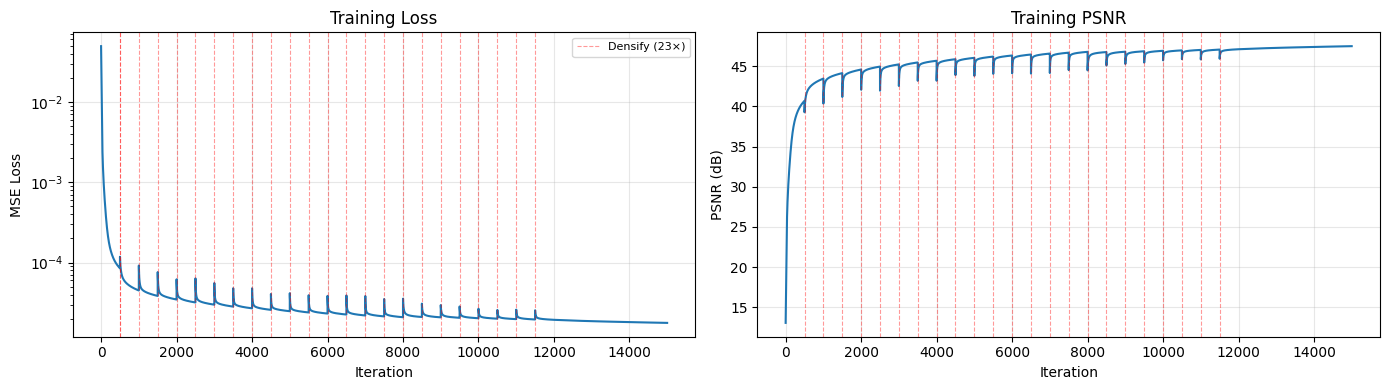

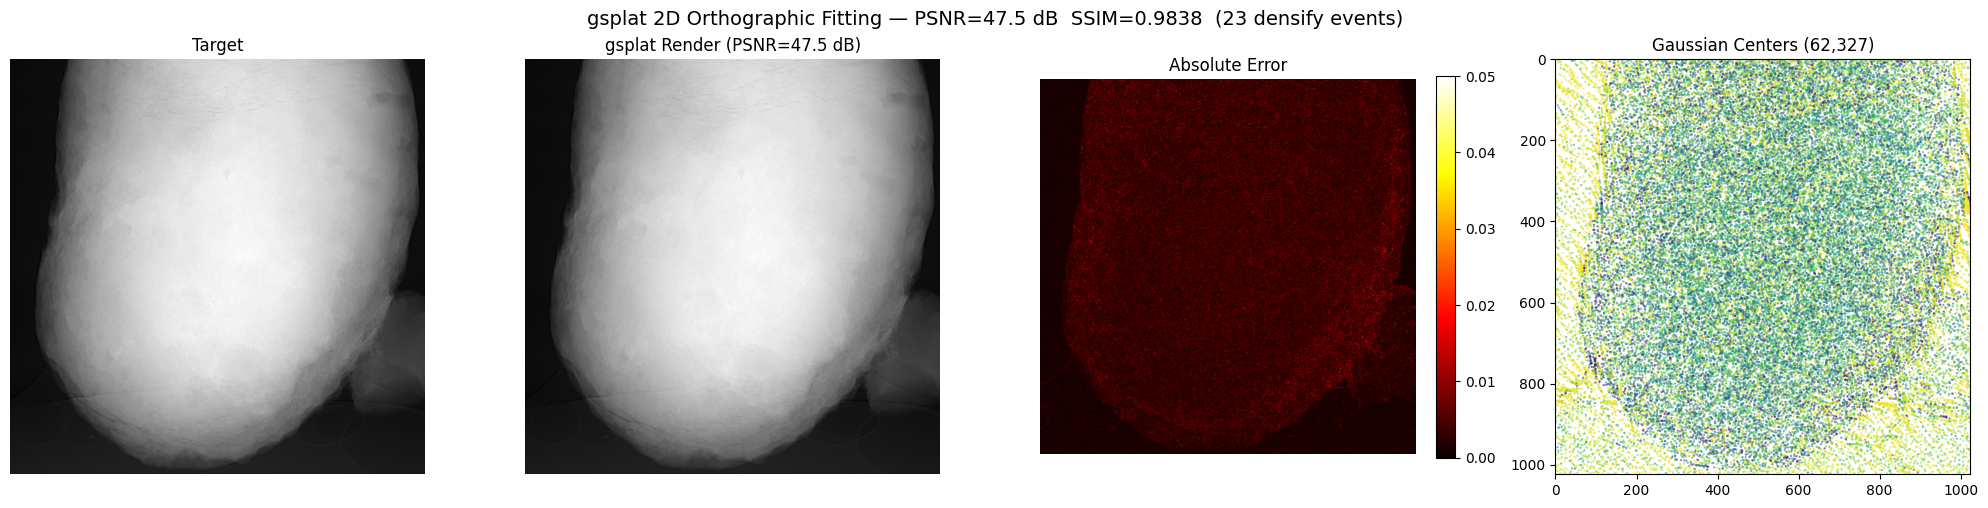


FINAL RESULTS
  PSNR:              47.50 dB
  SSIM:              0.9838
  Gaussians:         62,327
  Densify events:    23
  Model size:        2.99 MB
  Compression ratio: 0.70×
  Total time:        63.4s


In [14]:
# ── Final render ──────────────────────────────────────────────────────────
with torch.no_grad():
    final_render_p2, final_alpha_p2, _ = render(
        means, log_scales, quats, rgbs, opacities,
        viewmat, K, W, H,
    )

final_np_p2  = np.clip(final_render_p2[:, :, 0].cpu().numpy(), 0, 1)
error_np_p2  = np.abs(final_np_p2 - target_np)
final_mse_p2 = np.mean(error_np_p2 ** 2)
final_psnr_p2 = -10 * np.log10(final_mse_p2 + 1e-10)
final_ssim_p2 = ssim(target_np, final_np_p2, data_range=1.0)

# ── Loss & PSNR curves with densification markers ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].semilogy(all_losses)
for di in densify_iters:
    axes[0].axvline(x=di, color='r', linestyle='--', alpha=0.4, linewidth=0.8)
if densify_iters:
    axes[0].axvline(x=densify_iters[0], color='r', linestyle='--', alpha=0.4,
                    linewidth=0.8, label=f'Densify ({len(densify_iters)}×)')
    axes[0].legend(fontsize=8)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(all_psnrs)
for di in densify_iters:
    axes[1].axvline(x=di, color='r', linestyle='--', alpha=0.4, linewidth=0.8)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('PSNR (dB)')
axes[1].set_title('Training PSNR')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Side-by-side comparison ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(target_np, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Target')
axes[0].axis('off')

axes[1].imshow(final_np_p2, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'gsplat Render (PSNR={final_psnr_p2:.1f} dB)')
axes[1].axis('off')

im = axes[2].imshow(error_np_p2, cmap='hot', vmin=0, vmax=0.05)
axes[2].set_title('Absolute Error')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)

# Scatter plot of Gaussian positions (subsample for viz)
means_np = means.detach().cpu().numpy()
opac_np  = torch.sigmoid(opacities).detach().cpu().numpy()
n_show   = min(50000, means_np.shape[0])
idx_show = np.random.choice(means_np.shape[0], n_show, replace=False)
axes[3].scatter(means_np[idx_show, 0], means_np[idx_show, 1],
                c=opac_np[idx_show], cmap='viridis', s=0.5, alpha=0.5)
axes[3].set_xlim(0, W)
axes[3].set_ylim(H, 0)  # flip y to match image coords
axes[3].set_title(f'Gaussian Centers ({means.shape[0]:,})')
axes[3].set_aspect('equal')

plt.suptitle(f'gsplat 2D Orthographic Fitting — PSNR={final_psnr_p2:.1f} dB  '
             f'SSIM={final_ssim_p2:.4f}  ({len(densify_iters)} densify events)',
             fontsize=14)
plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────
n_active   = means.shape[0]
model_bytes = n_active * params_per_gaussian * 4
cr         = original_bytes / model_bytes

print(f"\n{'='*50}")
print(f"FINAL RESULTS")
print(f"{'='*50}")
print(f"  PSNR:              {final_psnr_p2:.2f} dB")
print(f"  SSIM:              {final_ssim_p2:.4f}")
print(f"  Gaussians:         {n_active:,}")
print(f"  Densify events:    {len(densify_iters)}")
print(f"  Model size:        {model_bytes / 1e6:.2f} MB")
print(f"  Compression ratio: {cr:.2f}×")
print(f"  Total time:        {elapsed:.1f}s")


## 11. Inter-Frame Delta Compression (Image 1 → Image 2)

**Idea:** The two projections are very similar. Instead of fitting image 2 from scratch,
we fine-tune the image-1 Gaussians to image 2. The resulting **per-Gaussian parameter deltas**
$\Delta_i = \theta_i^{(2)} - \theta_i^{(1)}$ should be small and clustered.

**Pipeline:**
1. **Snapshot** the image-1 fit (`means₁, log_scales₁, quats₁, rgbs₁, opacities₁`)
2. **Fine-tune** to image 2 → produce `means₂, …`
3. **Compute deltas** ∈ ℝ^{N×14}
4. **K-means** over the delta vectors — elbow rule to choose K
5. **Quantize**: replace each Gaussian's delta with its cluster centroid
6. **Reconstruct** image-1 params + quantized delta → rasterize → compare error vs. K

Snapshot of image-1 fit saved: 62,327 Gaussians
  means:      torch.Size([62327, 3])
  log_scales: torch.Size([62327, 3])
  quats:      torch.Size([62327, 4])
  rgbs:       torch.Size([62327, 3])
  opacities:  torch.Size([62327])

Image 2 — shape torch.Size([1024, 1024]), range [0.0000, 1.0000]


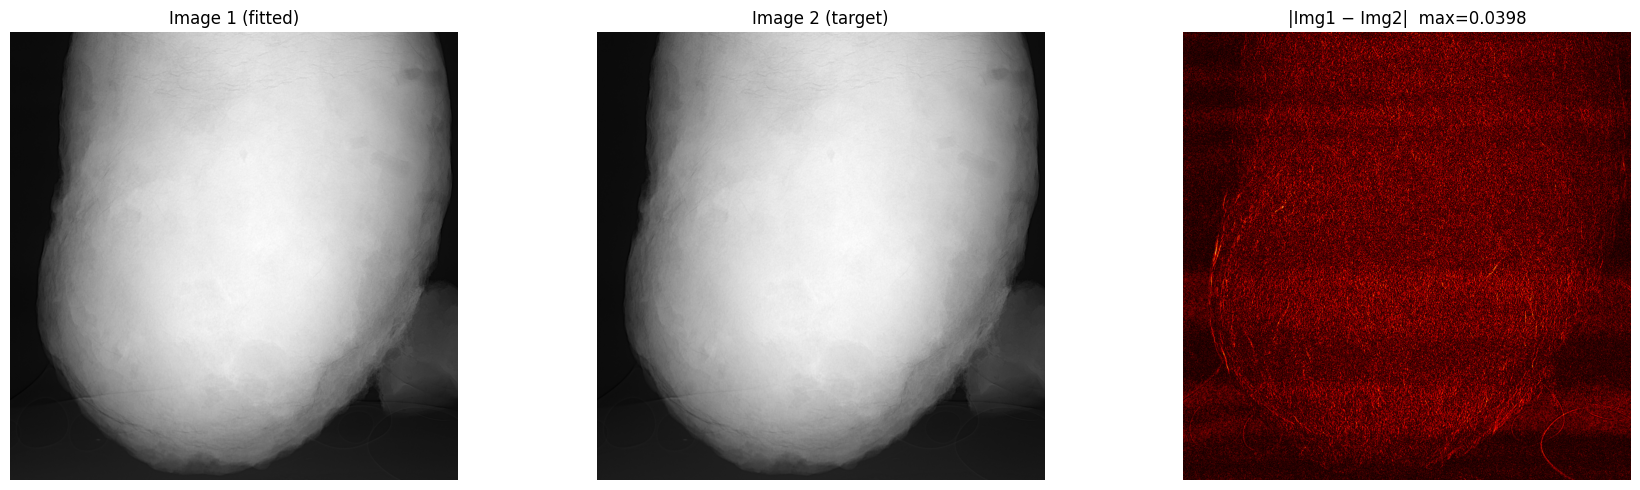

In [15]:
# ── 11.1  Snapshot the image-1 fitted parameters ─────────────────────────
# Detach and clone everything so the fine-tuning step below doesn't affect them.
snap1_means      = means.detach().clone()       # [N, 3]
snap1_log_scales = log_scales.detach().clone()  # [N, 3]
snap1_quats      = quats.detach().clone()       # [N, 4]
snap1_rgbs       = rgbs.detach().clone()        # [N, 3]
snap1_opacities  = opacities.detach().clone()   # [N]

N_SNAP = snap1_means.shape[0]
print(f"Snapshot of image-1 fit saved: {N_SNAP:,} Gaussians")
print(f"  means:      {snap1_means.shape}")
print(f"  log_scales: {snap1_log_scales.shape}")
print(f"  quats:      {snap1_quats.shape}")
print(f"  rgbs:       {snap1_rgbs.shape}")
print(f"  opacities:  {snap1_opacities.shape}")

# ── 11.2  Load second projection as new target ────────────────────────────
# volume[:, :, 1] is the second projection slice
image_gray2 = volume[:, :, 1].clone()
img_min2, img_max2 = image_gray2.min(), image_gray2.max()
image_gray2 = (image_gray2 - img_min2) / (img_max2 - img_min2 + 1e-8)
gt_image2 = image_gray2.unsqueeze(-1).repeat(1, 1, 3).to(device)

print(f"\nImage 2 — shape {image_gray2.shape}, "
      f"range [{image_gray2.min():.4f}, {image_gray2.max():.4f}]")

# Visual side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(image_gray.cpu().numpy(),  cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Image 1 (fitted)');   axes[0].axis('off')
axes[1].imshow(image_gray2.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Image 2 (target)');   axes[1].axis('off')
diff_np = np.abs(image_gray.cpu().numpy() - image_gray2.cpu().numpy())
axes[2].imshow(diff_np, cmap='hot', vmin=0, vmax=diff_np.max())
axes[2].set_title(f'|Img1 − Img2|  max={diff_np.max():.4f}')
axes[2].axis('off')
plt.tight_layout()
plt.show()


In [23]:
ft_means_x, ft_means_y, ft_means_z

(tensor[3] x∈[0.930, 769.505] μ=438.245 σ=395.111 grad=None cuda:0 [769.505, 544.300, 0.930],
 tensor[3] x∈[0.813, 360.674] μ=123.699 σ=205.274 grad=None cuda:0 [360.674, 9.609, 0.813],
 tensor[3] x∈[0.912, 450.038] μ=271.381 σ=238.224 grad=None cuda:0 [450.038, 363.192, 0.912])

Fine-tuning to image 2:  10000 iterations, LR scale=0.3
  [    0/10000]  loss=0.000034  PSNR=44.68 dB
  [  200/10000]  loss=0.000023  PSNR=46.29 dB
  [  400/10000]  loss=0.000023  PSNR=46.42 dB
  [  600/10000]  loss=0.000022  PSNR=46.50 dB
  [  800/10000]  loss=0.000022  PSNR=46.56 dB
  [ 1000/10000]  loss=0.000022  PSNR=46.61 dB
  [ 1200/10000]  loss=0.000022  PSNR=46.65 dB
  [ 1400/10000]  loss=0.000021  PSNR=46.68 dB
  [ 1600/10000]  loss=0.000021  PSNR=46.71 dB
  [ 1800/10000]  loss=0.000021  PSNR=46.74 dB
  [ 2000/10000]  loss=0.000021  PSNR=46.77 dB
  [ 2200/10000]  loss=0.000021  PSNR=46.79 dB
  [ 2400/10000]  loss=0.000021  PSNR=46.81 dB
  [ 2600/10000]  loss=0.000021  PSNR=46.83 dB
  [ 2800/10000]  loss=0.000021  PSNR=46.85 dB
  [ 3000/10000]  loss=0.000021  PSNR=46.87 dB
  [ 3200/10000]  loss=0.000020  PSNR=46.89 dB
  [ 3400/10000]  loss=0.000020  PSNR=46.91 dB
  [ 3600/10000]  loss=0.000020  PSNR=46.93 dB
  [ 3800/10000]  loss=0.000020  PSNR=46.94 dB
  [ 4000/10000]  loss=0.

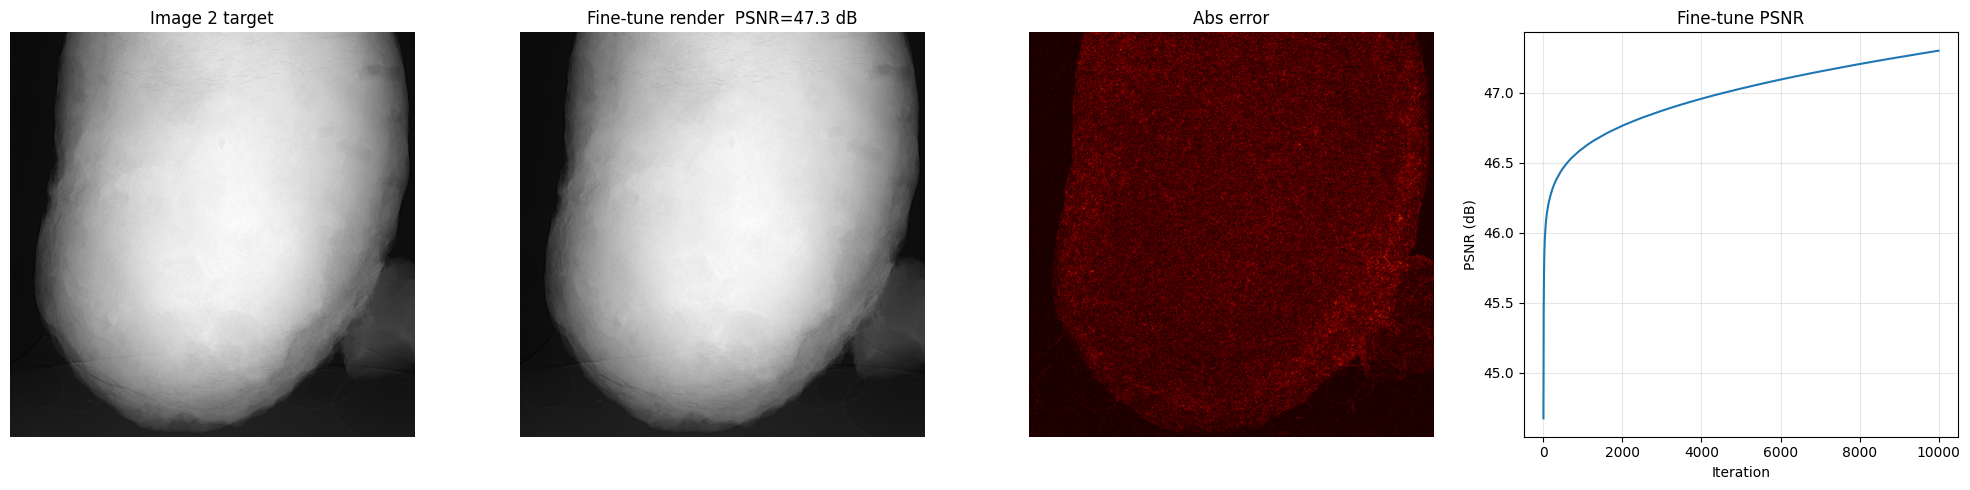

In [29]:
# ── 11.3  Fine-tune the snapshot Gaussians to image 2 ────────────────────
# Start parameters: warm-initialised from the image-1 fit.
NUM_ITER_FT = 10000    # fewer iterations — already close to solution
LR_FT_SCALE = 0.3    # gentler learning rates to stay near image-1 solution

# ft_means      = snap1_means.clone().requires_grad_(True)
ft_means_x = snap1_means[:, 0].clone().requires_grad_(True)
ft_means_y = snap1_means[:, 1].clone().requires_grad_(True)
ft_means_z = snap1_means[:, 2].clone().requires_grad_(True)
ft_log_scales = snap1_log_scales.clone().requires_grad_(True)
ft_quats      = snap1_quats.clone().requires_grad_(True)
ft_rgbs       = snap1_rgbs.clone().requires_grad_(True)
ft_opacities  = snap1_opacities.clone().requires_grad_(True)

optimizer_ft = optim.Adam([
    # {'params': [ft_means_x],      'lr': LR_MEANS     * LR_FT_SCALE, 'name': 'means'},
    {'params': [ft_means_y],      'lr': LR_MEANS     * LR_FT_SCALE, 'name': 'means'},
    {'params': [ft_means_z],      'lr': LR_MEANS     * LR_FT_SCALE, 'name': 'means'},
    {'params': [ft_log_scales], 'lr': LR_SCALES    * LR_FT_SCALE, 'name': 'scales'},
    {'params': [ft_quats],      'lr': LR_QUATS     * LR_FT_SCALE, 'name': 'quats'},
    {'params': [ft_rgbs],       'lr': LR_RGBS      * LR_FT_SCALE, 'name': 'rgbs'},
    {'params': [ft_opacities],  'lr': LR_OPACITIES * LR_FT_SCALE, 'name': 'opacities'},
])
scaler_ft = GradScaler(enabled=USE_FP16)

ft_loss_history = []
ft_psnr_history = []

print(f"Fine-tuning to image 2:  {NUM_ITER_FT} iterations, LR scale={LR_FT_SCALE}")
print("=" * 60)

t_ft = time.time()
for it in range(NUM_ITER_FT):
    with autocast(device_type='cuda', dtype=torch.float16, enabled=USE_FP16):
        ft_means = torch.stack([ft_means_x, ft_means_y, ft_means_z], 1)
        rendered_ft, _, _ = render(
            ft_means, ft_log_scales, ft_quats, ft_rgbs, ft_opacities,
            viewmat, K, W, H,
        )
        loss_ft = mse_loss_fn(rendered_ft, gt_image2)

    optimizer_ft.zero_grad()
    scaler_ft.scale(loss_ft).backward()
    scaler_ft.step(optimizer_ft)
    scaler_ft.update()

    # Enforce grayscale constraint
    with torch.no_grad():
        rgb_mean_ft = ft_rgbs.data.mean(dim=-1, keepdim=True)
        ft_rgbs.data.copy_(rgb_mean_ft.expand_as(ft_rgbs))

    lv = loss_ft.item()
    ps = -10 * math.log10(lv + 1e-10)
    ft_loss_history.append(lv)
    ft_psnr_history.append(ps)

    if it % 200 == 0 or it == NUM_ITER_FT - 1:
        print(f"  [{it:5d}/{NUM_ITER_FT}]  loss={lv:.6f}  PSNR={ps:.2f} dB")

elapsed_ft = time.time() - t_ft
print(f"\n✅ Fine-tune done in {elapsed_ft:.1f}s  —  final PSNR={ft_psnr_history[-1]:.2f} dB")

# Detach fine-tuned params → snap2
snap2_means      = ft_means.detach().clone()
snap2_log_scales = ft_log_scales.detach().clone()
snap2_quats      = ft_quats.detach().clone()
snap2_rgbs       = ft_rgbs.detach().clone()
snap2_opacities  = ft_opacities.detach().clone()

# Quick visual
with torch.no_grad():
    render_ft2, _, _ = render(snap2_means, snap2_log_scales, snap2_quats,
                               snap2_rgbs, snap2_opacities, viewmat, K, W, H)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(image_gray2.cpu().numpy(),       cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Image 2 target');            axes[0].axis('off')
axes[1].imshow(render_ft2[:,:,0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Fine-tune render  PSNR={ft_psnr_history[-1]:.1f} dB')
axes[1].axis('off')
err_ft = np.abs(render_ft2[:,:,0].cpu().numpy() - image_gray2.cpu().numpy())
axes[2].imshow(err_ft, cmap='hot')
axes[2].set_title('Abs error'); axes[2].axis('off')

axes[3].plot(ft_psnr_history)
axes[3].set_xlabel('Iteration'); axes[3].set_ylabel('PSNR (dB)')
axes[3].set_title('Fine-tune PSNR'); axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Delta matrix: 62,327 Gaussians × 14 parameters

  Parameter            mean        std        min        max
------------------------------------------------------------
  Δmean_x           0.00905    0.10972   -0.80695    0.98492
  Δmean_y           0.00005    0.02348   -0.50452    0.47247
  Δmean_z           0.00000    0.00000    0.00000    0.00000
  Δscale_x          0.00029    0.14082   -1.17888    0.80693
  Δscale_y          0.00368    0.13770   -1.08683    1.14014
  Δscale_z          0.00000    0.00000    0.00000    0.00000
  Δquat_w          -0.00167    0.00931   -0.20061    0.12026
  Δquat_x           0.00000    0.00000    0.00000    0.00000
  Δquat_y           0.00000    0.00000    0.00000    0.00000
  Δquat_z          -0.00008    0.04432   -0.29688    0.27790
  Δrgb_r            0.01423    0.08549   -0.52762    0.54289
  Δrgb_g            0.01423    0.08549   -0.52762    0.54289
  Δrgb_b            0.01423    0.08549   -0.52762    0.54289
  Δopacity          0.00114    0.3855

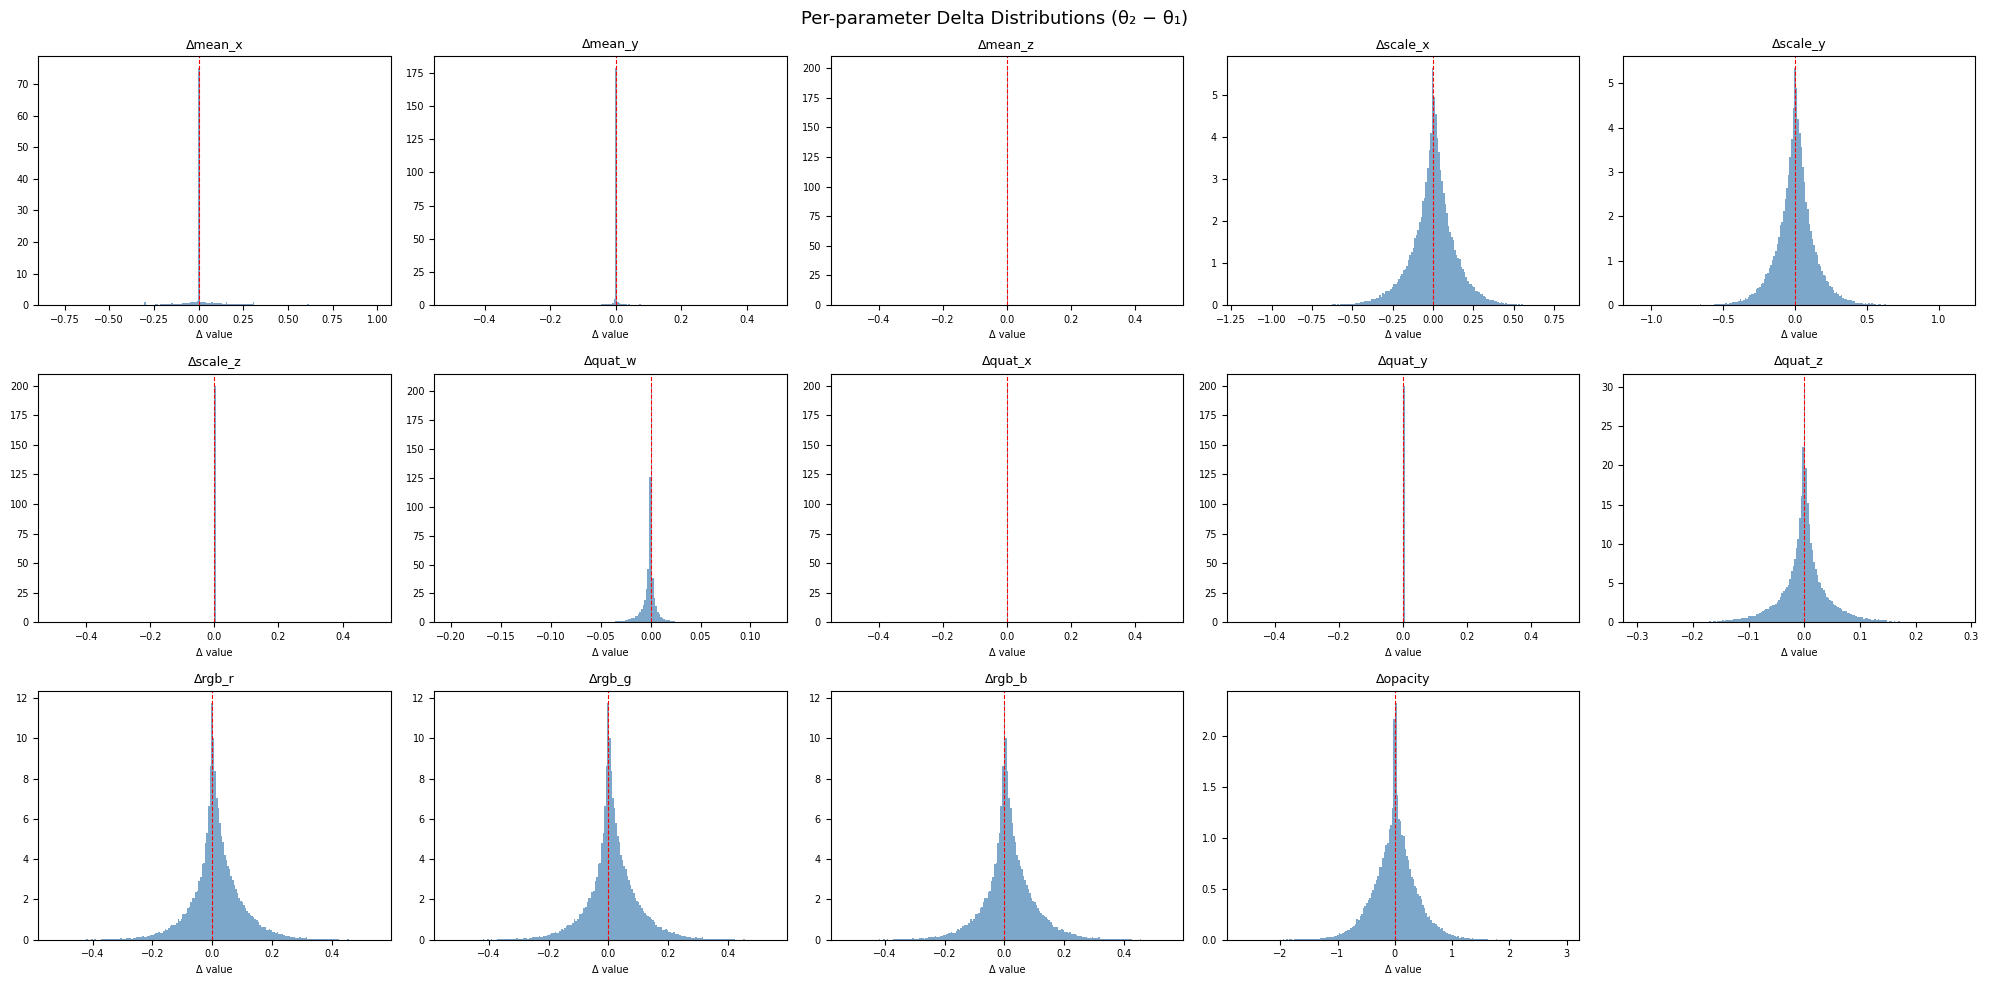


Per-Gaussian ‖Δ‖₂:  mean=0.39547  std=0.26144  max=3.04952


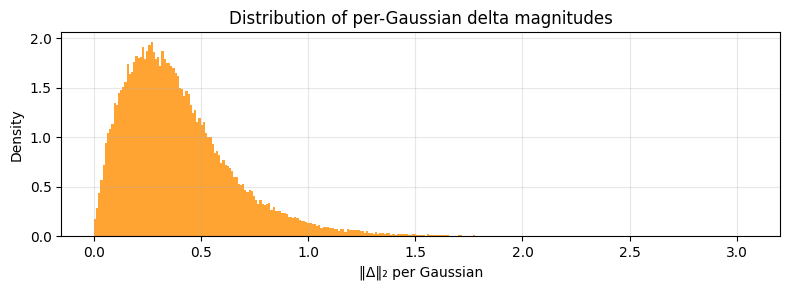

In [30]:
# ── 11.4  Compute per-Gaussian deltas and statistical analysis ────────────
# Delta vector per Gaussian:  Δ = θ₂ − θ₁,  shape [N, 14]
#   cols 0-2   : Δ means      (3 floats)
#   cols 3-5   : Δ log_scales (3 floats)
#   cols 6-9   : Δ quats      (4 floats)
#   cols 10-12 : Δ rgbs       (3 floats)
#   col  13    : Δ opacities  (1 float)

delta_means      = (snap2_means      - snap1_means).cpu()
delta_log_scales = (snap2_log_scales - snap1_log_scales).cpu()
delta_quats      = (snap2_quats      - snap1_quats).cpu()
delta_rgbs       = (snap2_rgbs       - snap1_rgbs).cpu()
delta_opacities  = (snap2_opacities  - snap1_opacities).cpu().unsqueeze(-1)

delta_all = torch.cat([
    delta_means,        # [N,3]
    delta_log_scales,   # [N,3]
    delta_quats,        # [N,4]
    delta_rgbs,         # [N,3]
    delta_opacities,    # [N,1]
], dim=-1).numpy()      # [N, 14]

param_names = (
    ['Δmean_x', 'Δmean_y', 'Δmean_z'] +
    ['Δscale_x', 'Δscale_y', 'Δscale_z'] +
    ['Δquat_w', 'Δquat_x', 'Δquat_y', 'Δquat_z'] +
    ['Δrgb_r', 'Δrgb_g', 'Δrgb_b'] +
    ['Δopacity']
)

N_G, D = delta_all.shape
print(f"Delta matrix: {N_G:,} Gaussians × {D} parameters")
print()
print(f"  {'Parameter':<14} {'mean':>10} {'std':>10} {'min':>10} {'max':>10}")
print("-" * 60)
for i, pname in enumerate(param_names):
    col = delta_all[:, i]
    print(f"  {pname:<14} {col.mean():>10.5f} {col.std():>10.5f} "
          f"{col.min():>10.5f} {col.max():>10.5f}")

# ── Per-parameter delta distributions ──────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(20, 10))
axes = axes.flatten()
for i, pname in enumerate(param_names):
    col = delta_all[:, i]
    axes[i].hist(col, bins=200, density=True, color='steelblue', alpha=0.7)
    axes[i].set_title(pname, fontsize=9)
    axes[i].set_xlabel('Δ value', fontsize=7)
    axes[i].tick_params(labelsize=7)
    axes[i].axvline(0, color='r', linewidth=0.8, linestyle='--')

# Hide the last unused subplot (14 params in 3×5 grid = 15 slots)
axes[-1].set_visible(False)

plt.suptitle('Per-parameter Delta Distributions (θ₂ − θ₁)', fontsize=13)
plt.tight_layout()
plt.show()

# ── Per-Gaussian L2 norm of the delta vector ─────────────────────────────
delta_norms = np.linalg.norm(delta_all, axis=1)
print(f"\nPer-Gaussian ‖Δ‖₂:  mean={delta_norms.mean():.5f}  "
      f"std={delta_norms.std():.5f}  max={delta_norms.max():.5f}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(delta_norms, bins=300, density=True, color='darkorange', alpha=0.8)
ax.set_xlabel('‖Δ‖₂ per Gaussian')
ax.set_ylabel('Density')
ax.set_title('Distribution of per-Gaussian delta magnitudes')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Running K-means sweep (MiniBatchKMeans, 62,327 Gaussians × 14 dims)
K values: [256, 512, 1024, 2048]

  K=  256  inertia=140,794.7
  K=  512  inertia=115,887.2
  K= 1024  inertia=91,960.5
  K= 2048  inertia=74,067.6


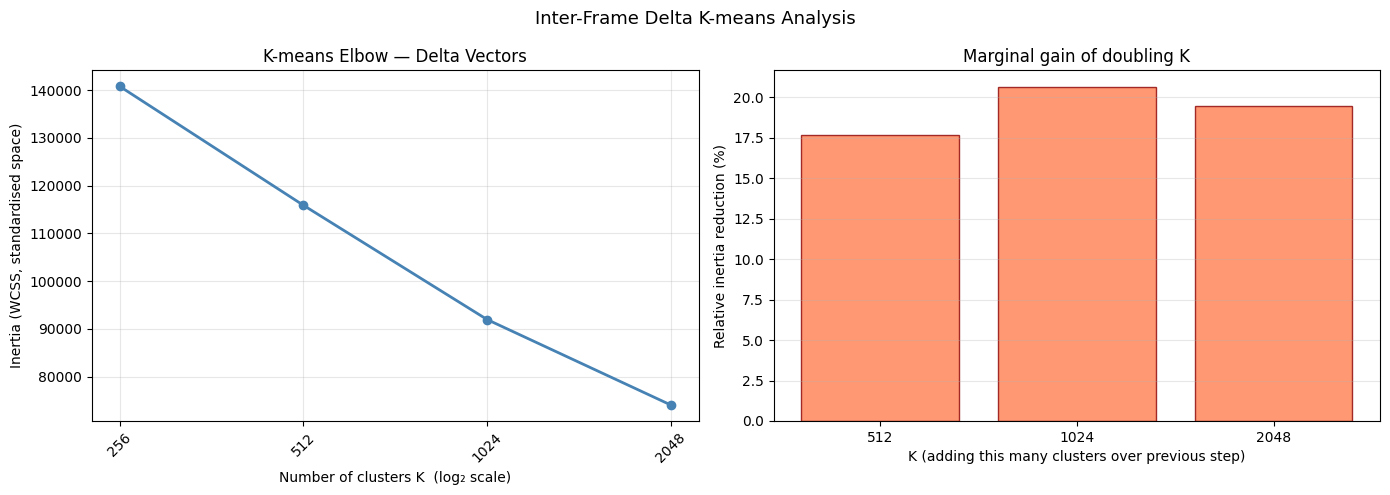


     K        Inertia   Rel. reduction
----------------------------------------
   256      140,794.7                —
   512      115,887.2            17.7%
  1024       91,960.5            20.6%
  2048       74,067.6            19.5%


In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans

# ── 11.5  K-means elbow analysis on the delta vectors ────────────────────
# Standardize so every dimension contributes equally to the distance metric
scaler = StandardScaler()
delta_scaled = scaler.fit_transform(delta_all)   # [N, 14], zero-mean unit-std per col

# K values to sweep — log-spaced from 2 to 1024
K_VALUES = [256, 512, 1024, 2048]

inertias = []
print(f"Running K-means sweep (MiniBatchKMeans, {N_G:,} Gaussians × {D} dims)")
print(f"K values: {K_VALUES}\n")

for k in K_VALUES:
    km = MiniBatchKMeans(
        n_clusters=k,
        init='k-means++',
        n_init=3,
        max_iter=300,
        batch_size=min(10_000, N_G),
        random_state=42,
        verbose=0,
    )
    km.fit(delta_scaled)
    inertias.append(km.inertia_)
    print(f"  K={k:5d}  inertia={km.inertia_:,.1f}")

inertias = np.array(inertias)

# ── Elbow plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_VALUES, inertias, 'o-', color='steelblue', linewidth=2)
axes[0].set_xscale('log', base=2)
axes[0].set_xlabel('Number of clusters K  (log₂ scale)')
axes[0].set_ylabel('Inertia (WCSS, standardised space)')
axes[0].set_title('K-means Elbow — Delta Vectors')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(K_VALUES)
axes[0].set_xticklabels([str(k) for k in K_VALUES], rotation=45)

# Relative reduction: (inertia[k-1] - inertia[k]) / inertia[k-1]
rel_reductions = np.diff(inertias) / inertias[:-1]
axes[1].bar([str(k) for k in K_VALUES[1:]], -rel_reductions * 100,
            color='coral', alpha=0.8, edgecolor='darkred')
axes[1].set_xlabel('K (adding this many clusters over previous step)')
axes[1].set_ylabel('Relative inertia reduction (%)')
axes[1].set_title('Marginal gain of doubling K')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Inter-Frame Delta K-means Analysis', fontsize=13)
plt.tight_layout()
plt.show()

# Print table
print(f"\n{'K':>6} {'Inertia':>14} {'Rel. reduction':>16}")
print("-" * 40)
for i, k in enumerate(K_VALUES):
    rr = f"{-rel_reductions[i-1]*100:.1f}%" if i > 0 else "—"
    print(f"{k:>6} {inertias[i]:>14,.1f} {rr:>16}")


Reference (unquantised fine-tune):  PSNR=47.30 dB  SSIM=0.9831

  K= 256  PSNR=42.63 dB  SSIM=0.9699  |codebook=7.2 kB  indices=62.3 kB|
  K= 512  PSNR=42.89 dB  SSIM=0.9710  |codebook=14.3 kB  indices=70.1 kB|
  K=1024  PSNR=43.28 dB  SSIM=0.9725  |codebook=28.7 kB  indices=77.9 kB|


Reference (unquantised fine-tune):  PSNR=47.30 dB  SSIM=0.9831

  K= 256  PSNR=42.63 dB  SSIM=0.9699  |codebook=7.2 kB  indices=62.3 kB|
  K= 512  PSNR=42.89 dB  SSIM=0.9710  |codebook=14.3 kB  indices=70.1 kB|
  K=1024  PSNR=43.28 dB  SSIM=0.9725  |codebook=28.7 kB  indices=77.9 kB|


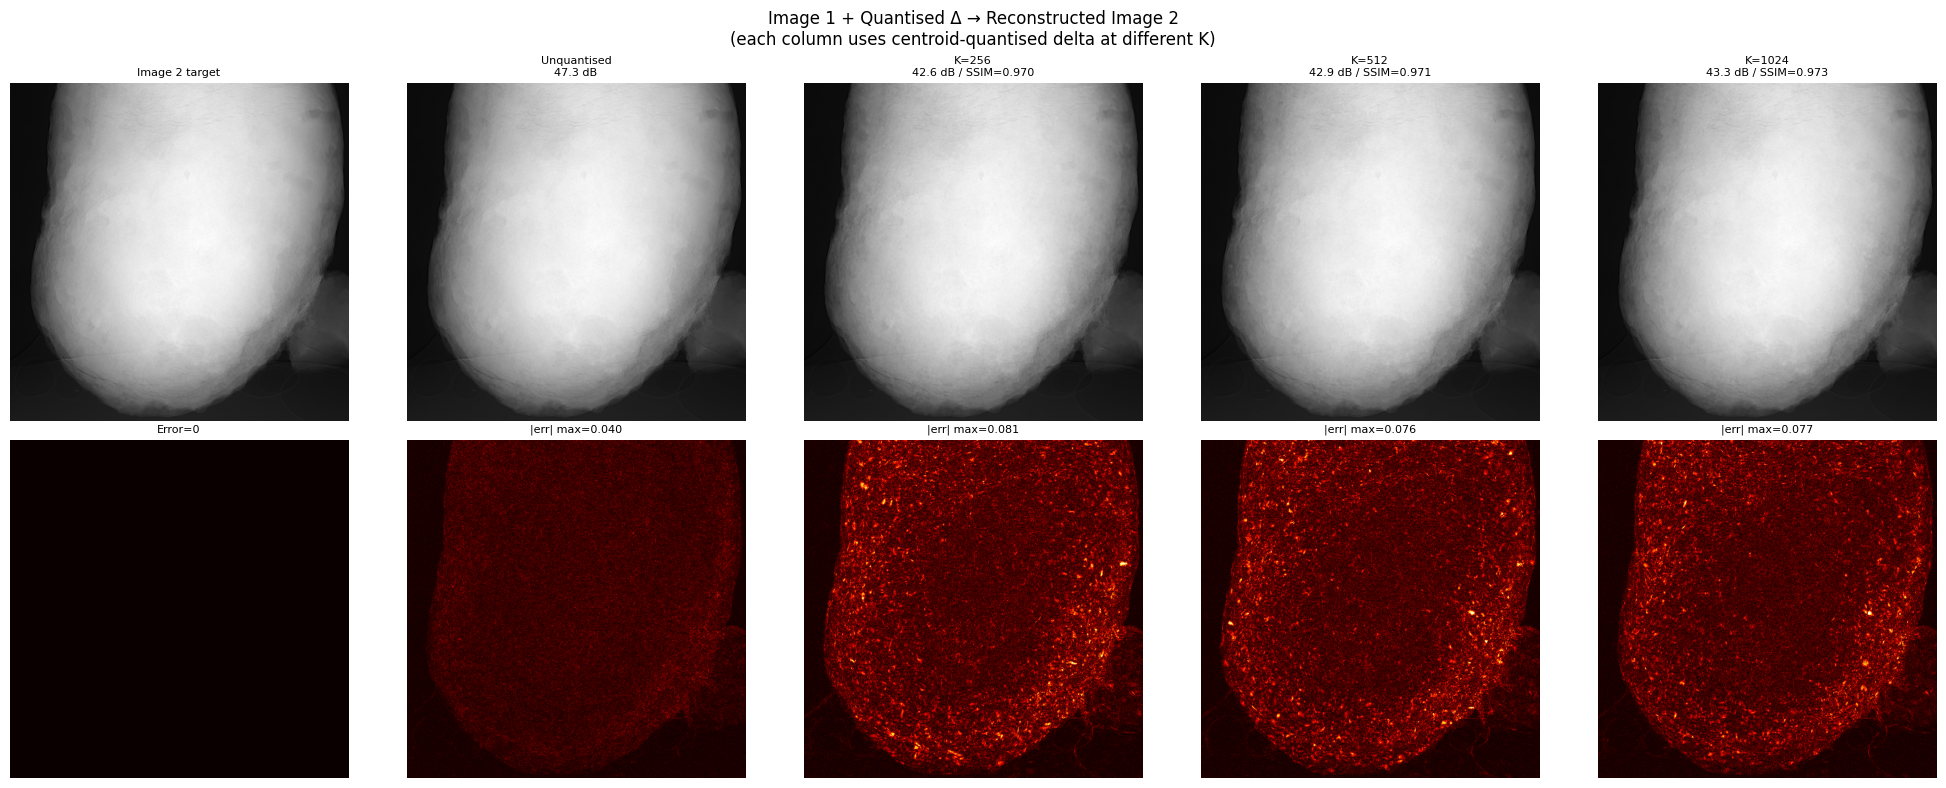

Reference (unquantised fine-tune):  PSNR=47.30 dB  SSIM=0.9831

  K= 256  PSNR=42.63 dB  SSIM=0.9699  |codebook=7.2 kB  indices=62.3 kB|
  K= 512  PSNR=42.89 dB  SSIM=0.9710  |codebook=14.3 kB  indices=70.1 kB|
  K=1024  PSNR=43.28 dB  SSIM=0.9725  |codebook=28.7 kB  indices=77.9 kB|


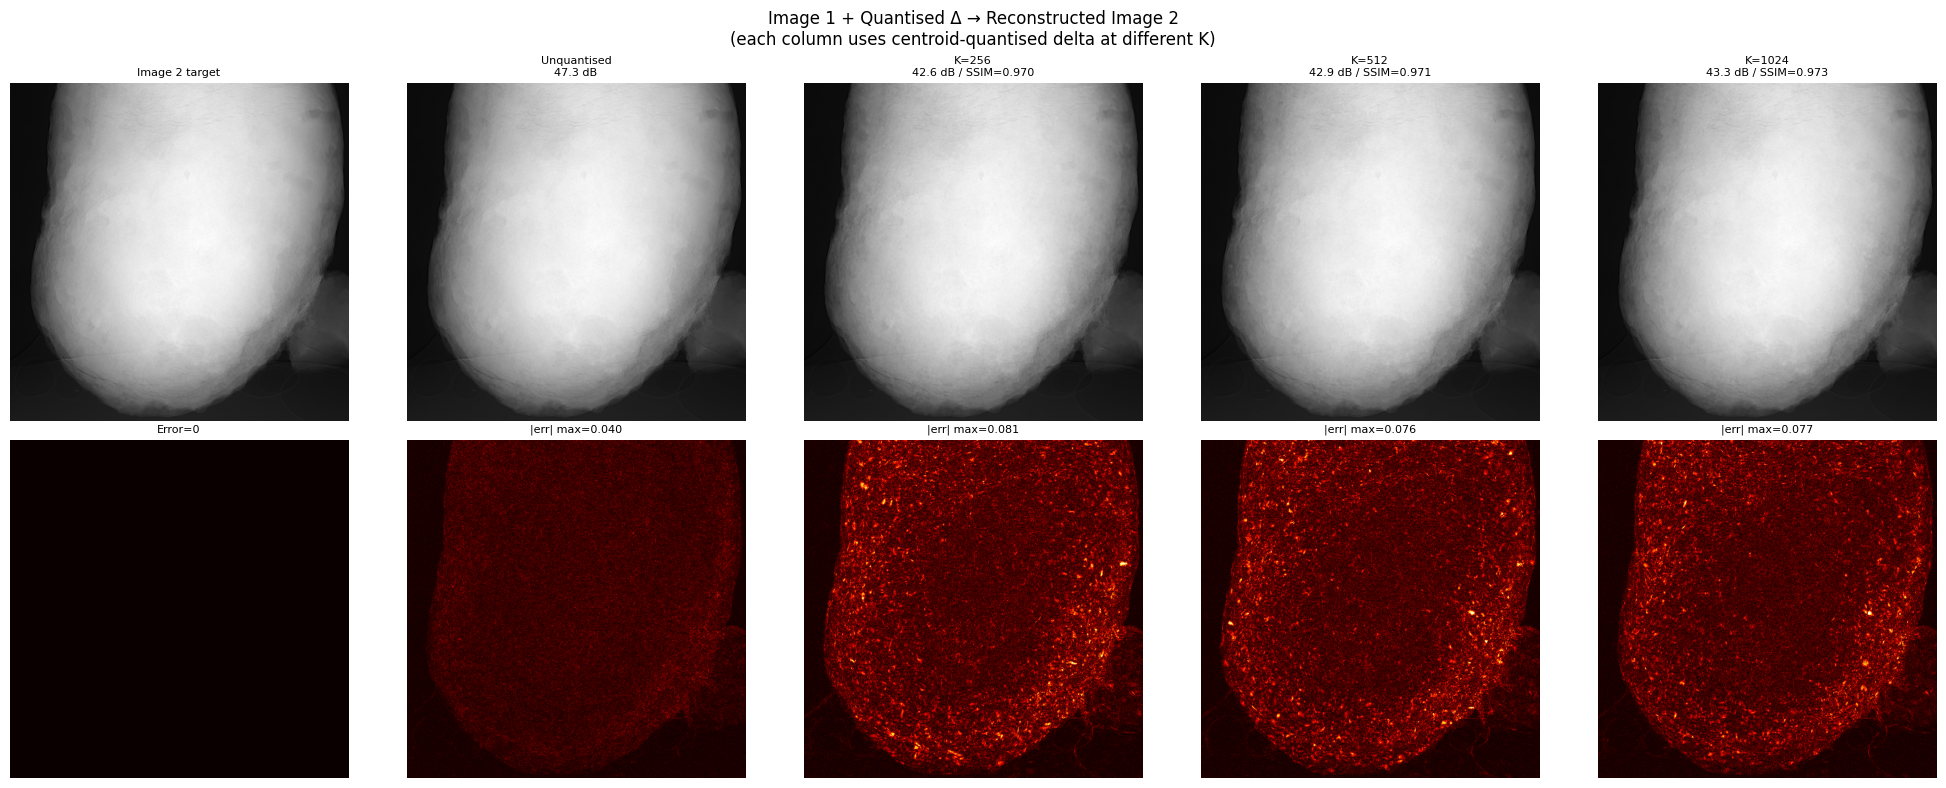

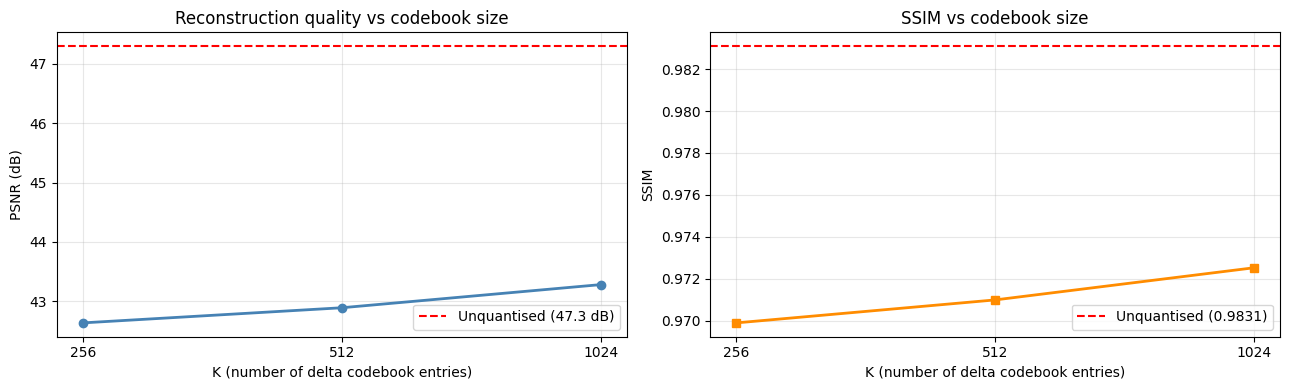

In [39]:
from skimage.metrics import structural_similarity as ssim

# ── 11.6  Quantized delta reconstruction: image1_params + quantized_Δ ────
# For each candidate K, replace every Gaussian's delta with its centroid,
# then reconstruct θ₁ + Δ_quantised and rasterise.

K_EVAL = [256, 512, 1024]   # subset of K_VALUES to visualise

# Reference: unquantised fine-tune render
with torch.no_grad():
    ref_render, _, _ = render(snap2_means, snap2_log_scales, snap2_quats,
                               snap2_rgbs, snap2_opacities, viewmat, K, W, H)
ref_np = np.clip(ref_render[:,:,0].cpu().numpy(), 0, 1)
target2_np = image_gray2.cpu().numpy()

ref_psnr = -10*np.log10(np.mean((ref_np - target2_np)**2) + 1e-10)
ref_ssim = ssim(target2_np, ref_np, data_range=1.0)

print(f"Reference (unquantised fine-tune):  PSNR={ref_psnr:.2f} dB  SSIM={ref_ssim:.4f}\n")

# Helper: split flat delta vector back into parameter groups
# cols: 0-2 → means, 3-5 → log_scales, 6-9 → quats, 10-12 → rgbs, 13 → opacities
def split_delta(delta_np):
    d = torch.from_numpy(delta_np).float().to(device)
    return (d[:, 0:3], d[:, 3:6], d[:, 6:10], d[:, 10:13], d[:, 13])

results = []  # (K, psnr, ssim, render_np)

for k in K_EVAL:
    # Fit K-means (reuse scaler from previous cell)
    km_q = MiniBatchKMeans(
        n_clusters=k, init='k-means++', n_init=5, max_iter=500,
        batch_size=min(10_000, N_G), random_state=42,
    )
    km_q.fit(delta_scaled)
    labels = km_q.labels_                        # [N]
    centroids_scaled = km_q.cluster_centers_     # [K, 14]

    # Map back to original scale
    centroids_orig = scaler.inverse_transform(centroids_scaled)  # [K, 14]

    # Assign each Gaussian its centroid delta
    quantised_delta = centroids_orig[labels]     # [N, 14]

    # Reconstruct: θ_rec = θ₁ + Δ_quantised
    d_m, d_s, d_q, d_r, d_o = split_delta(quantised_delta)
    rec_means      = snap1_means      + d_m
    rec_log_scales = snap1_log_scales + d_s
    rec_quats      = snap1_quats      + d_q
    rec_rgbs       = snap1_rgbs       + d_r
    rec_opacities  = snap1_opacities  + d_o

    with torch.no_grad():
        rec_render, _, _ = render(rec_means, rec_log_scales, rec_quats,
                                  rec_rgbs, rec_opacities, viewmat, K, W, H)

    rec_np = np.clip(rec_render[:,:,0].cpu().numpy(), 0, 1)
    p = -10*np.log10(np.mean((rec_np - target2_np)**2) + 1e-10)
    s = ssim(target2_np, rec_np, data_range=1.0)
    results.append((k, p, s, rec_np))

    # Storage estimate: codebook (K×14 floats) + indices (N × ceil(log2(K)) bits)
    bits_per_idx = math.ceil(math.log2(k))
    codebook_bytes = k * 14 * 4
    index_bytes    = math.ceil(N_G * bits_per_idx / 8)
    total_bytes    = codebook_bytes + index_bytes + snap1_means.shape[0] * 14 * 4  # base + delta

    print(f"  K={k:>4d}  PSNR={p:.2f} dB  SSIM={s:.4f}  "
          f"|codebook={codebook_bytes/1e3:.1f} kB  "
          f"indices={index_bytes/1e3:.1f} kB|")

# ── Visualisation: renders at each K ─────────────────────────────────────
n_cols = len(K_EVAL) + 2  # target + reference + one per K
fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 8))

# Top row: rendered images; Bottom row: absolute error vs target
def show(ax, img, title, cmap='gray', vmax=1):
    ax.imshow(img, cmap=cmap, vmin=0, vmax=vmax); ax.set_title(title, fontsize=8); ax.axis('off')

show(axes[0,0], target2_np, 'Image 2 target')
show(axes[1,0], np.abs(target2_np - target2_np), 'Error=0', cmap='hot', vmax=0.05)

show(axes[0,1], ref_np, f'Unquantised\n{ref_psnr:.1f} dB')
show(axes[1,1], np.abs(ref_np - target2_np), f'|err| max={np.abs(ref_np-target2_np).max():.3f}',
     cmap='hot', vmax=0.05)

for j, (k, p, s, rec_np) in enumerate(results):
    show(axes[0, j+2], rec_np, f'K={k}\n{p:.1f} dB / SSIM={s:.3f}')
    show(axes[1, j+2], np.abs(rec_np - target2_np),
         f'|err| max={np.abs(rec_np-target2_np).max():.3f}', cmap='hot', vmax=0.05)

plt.suptitle('Image 1 + Quantised Δ → Reconstructed Image 2\n'
             '(each column uses centroid-quantised delta at different K)', fontsize=12)
plt.tight_layout()
plt.show()

# ── PSNR vs K trade-off ───────────────────────────────────────────────────
ks   = [r[0] for r in results]
psnrs = [r[1] for r in results]
ssims = [r[2] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].semilogx(ks, psnrs, 'o-', color='steelblue', linewidth=2, base=2)
axes[0].axhline(ref_psnr, color='red', linestyle='--', label=f'Unquantised ({ref_psnr:.1f} dB)')
axes[0].set_xlabel('K (number of delta codebook entries)')
axes[0].set_ylabel('PSNR (dB)')
axes[0].set_title('Reconstruction quality vs codebook size')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(ks); axes[0].set_xticklabels([str(k) for k in ks])

axes[1].semilogx(ks, ssims, 's-', color='darkorange', linewidth=2, base=2)
axes[1].axhline(ref_ssim, color='red', linestyle='--', label=f'Unquantised ({ref_ssim:.4f})')
axes[1].set_xlabel('K (number of delta codebook entries)')
axes[1].set_ylabel('SSIM')
axes[1].set_title('SSIM vs codebook size')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(ks); axes[1].set_xticklabels([str(k) for k in ks])

plt.tight_layout()
plt.show()


## 12. Codebook Fine-tuning via Gradient Descent

Instead of keeping the 256 K-means centroids fixed, we fine-tune them directly against image 2.

**Setup:**
- Base Gaussians $X$ (`snap1_*`) are **frozen** — no gradients, no updates
- Learnable: codebook $C \in \mathbb{R}^{256 \times 14}$, initialised from K-means centroids
- Each Gaussian $i$ is assigned label $\ell_i \in \{0, \ldots, 255\}$ (fixed integer lookup from K-means)
- Reconstructed parameters: $\theta_i = X_i + C[\ell_i]$
- Loss: MSE between $\hat{Y} = \text{render}(\theta)$ and target $Y$ (image 2)
- Gradient flows only into the 256 rows of $C$ that were used; the indexing `C[labels]` accumulates gradients from all $N/256 \approx 393$ Gaussians per centroid on average

This is a **structured bottleneck fine-tune**: the full $N \times 14$ degree of freedom is compressed to $256 \times 14 = 3584$ free scalars.

Fitting K=4096 K-means on delta vectors (62,327 × 14)…
  Cluster sizes: min=1  mean=15  max=120
  Initial inertia (scaled space): 54,665.9

Before codebook fine-tune (K=4096):  PSNR=44.08 dB  SSIM=0.9757
Reference unquantised fine-tune:        PSNR=47.30 dB  SSIM=0.9831

Fine-tuning 4096 codebook vectors × 14 dims  (57344 free params)  for 2000 iterations…
  [    0/2000]  loss=0.000039  PSNR=44.08 dB
  [  200/2000]  loss=0.000022  PSNR=46.48 dB
  [  400/2000]  loss=0.000022  PSNR=46.52 dB
  [  600/2000]  loss=0.000022  PSNR=46.53 dB
  [  800/2000]  loss=0.000022  PSNR=46.54 dB
  [ 1000/2000]  loss=0.000022  PSNR=46.54 dB
  [ 1200/2000]  loss=0.000022  PSNR=46.54 dB
  [ 1400/2000]  loss=0.000022  PSNR=46.54 dB
  [ 1600/2000]  loss=0.000022  PSNR=46.54 dB
  [ 1800/2000]  loss=0.000022  PSNR=46.54 dB
  [ 1999/2000]  loss=0.000022  PSNR=46.55 dB

✅ Codebook fine-tune done in 7.3s

  Metric comparison (K=4096 codebook)
  Before codebook fine-tune : PSNR=44.08 dB  SSIM=0.9757
  After  codebo

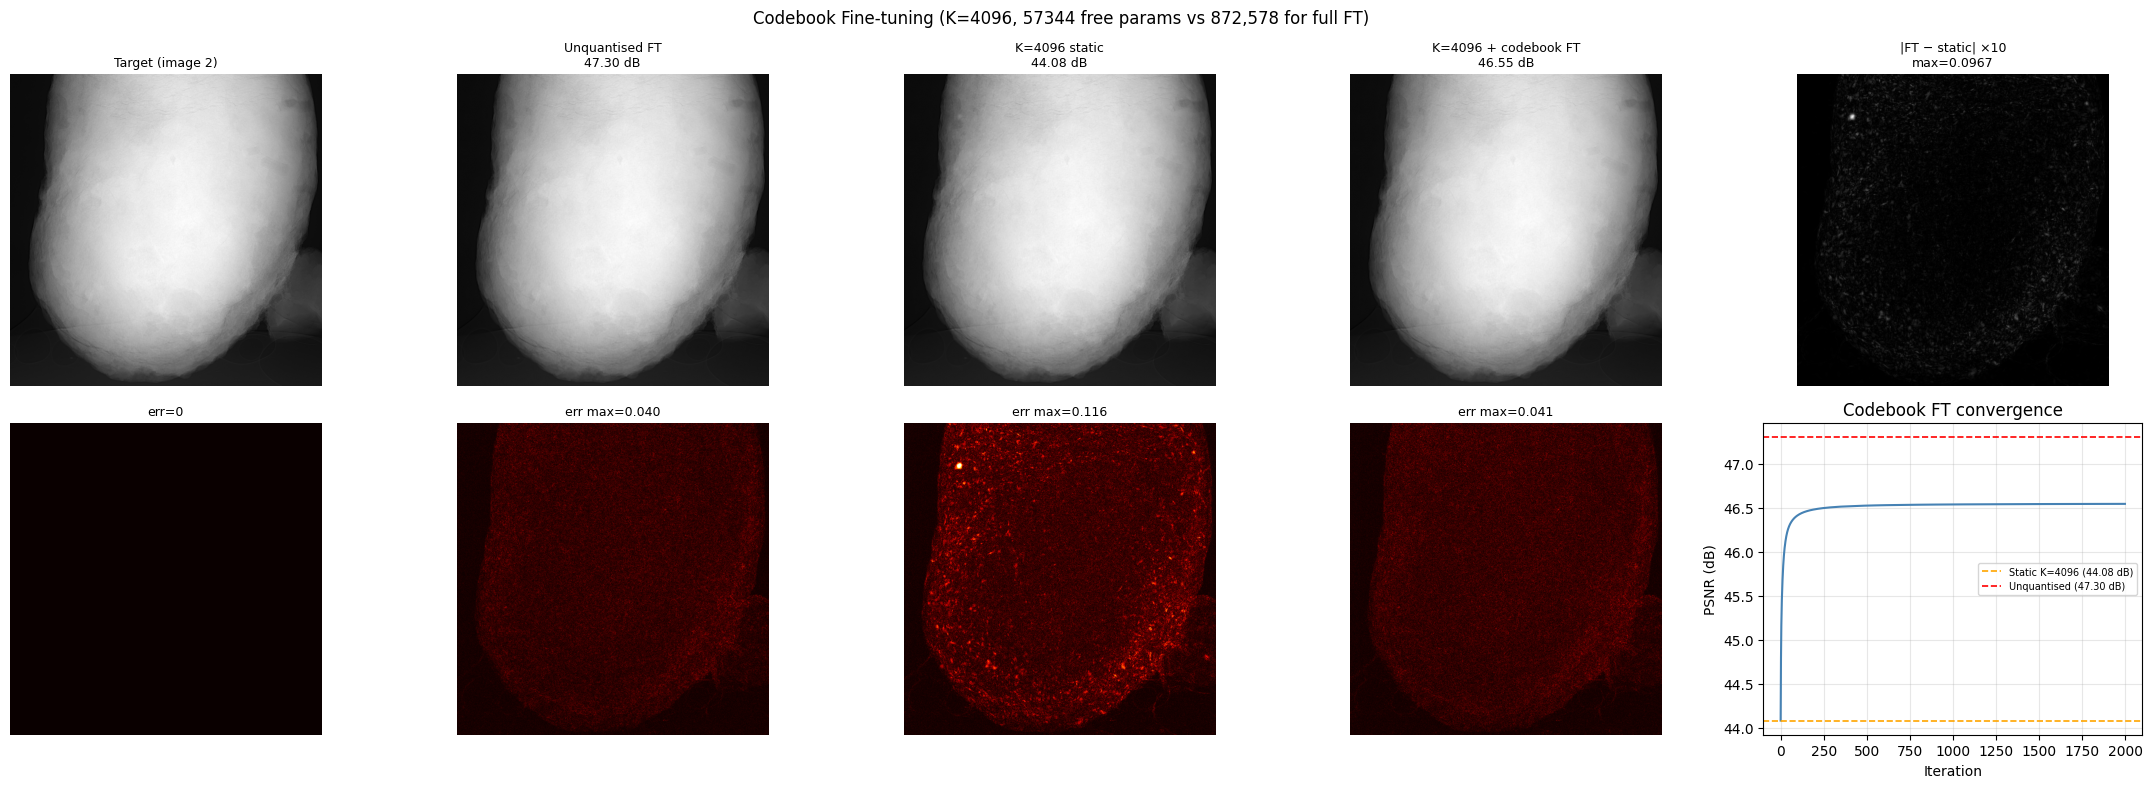

In [35]:
K_CB = 4096   # codebook size
NUM_ITER_CB = 2000
LR_CB = 5e-3  # conservative — each centroid drives ~N/K Gaussians

# ── 12.1  Fit K=512 K-means on deltas (deterministic seed) ───────────────
print(f"Fitting K={K_CB} K-means on delta vectors ({N_G:,} × {D})…")
km_cb = MiniBatchKMeans(
    n_clusters=K_CB, init='k-means++', n_init=10,
    max_iter=500, batch_size=min(10_000, N_G), random_state=42,
)
km_cb.fit(delta_scaled)
labels_cb   = km_cb.labels_                                   # [N] numpy int32
centroids_cb = scaler.inverse_transform(km_cb.cluster_centers_)  # [K, 14] original scale

print(f"  Cluster sizes: min={np.bincount(labels_cb).min()}  "
      f"mean={len(labels_cb)/K_CB:.0f}  max={np.bincount(labels_cb).max()}")
print(f"  Initial inertia (scaled space): {km_cb.inertia_:,.1f}\n")

# ── 12.2  Build frozen base tensors and learnable codebook ───────────────
# snap1_* are already detached — no grad will flow into them
base_means      = snap1_means.to(device)       # [N, 3]  — no requires_grad
base_log_scales = snap1_log_scales.to(device)  # [N, 3]
base_quats      = snap1_quats.to(device)       # [N, 4]
base_rgbs       = snap1_rgbs.to(device)        # [N, 3]
base_opacities  = snap1_opacities.to(device)   # [N]

# Codebook: [K, 14] — the ONLY learnable parameter
codebook = torch.tensor(centroids_cb, dtype=torch.float32, device=device,
                        requires_grad=True)

# Integer label tensor (fixed — not differentiable, not updated)
labels_t = torch.tensor(labels_cb, dtype=torch.long, device=device)  # [N]

optimizer_cb = torch.optim.Adam([codebook], lr=LR_CB)
scaler_cb = GradScaler(enabled=USE_FP16)

# Column slices within the 14-dim delta vector
S_M  = slice(0,  3)   # Δmeans      [N,3]
S_S  = slice(3,  6)   # Δlog_scales [N,3]
S_Q  = slice(6,  10)  # Δquats      [N,4]
S_R  = slice(10, 13)  # Δrgbs       [N,3]
S_O  = 13             # Δopacities  [N]

# ── Baseline: static K=512 quantisation (no fine-tune) ───────────────────
with torch.no_grad():
    delta_static = codebook[labels_t]                           # [N, 14]
    r0_means      = base_means      + delta_static[:, S_M]
    r0_log_scales = base_log_scales + delta_static[:, S_S]
    r0_quats      = base_quats      + delta_static[:, S_Q]
    r0_rgbs       = base_rgbs       + delta_static[:, S_R]
    r0_opacities  = base_opacities  + delta_static[:, S_O]
    r0_render, _, _ = render(r0_means, r0_log_scales, r0_quats,
                              r0_rgbs, r0_opacities, viewmat, K, W, H)
    r0_np = np.clip(r0_render[:,:,0].cpu().numpy(), 0, 1)

psnr_before = -10*np.log10(np.mean((r0_np - target2_np)**2) + 1e-10)
ssim_before = ssim(target2_np, r0_np, data_range=1.0)
print(f"Before codebook fine-tune (K={K_CB}):  PSNR={psnr_before:.2f} dB  SSIM={ssim_before:.4f}")
print(f"Reference unquantised fine-tune:        PSNR={ref_psnr:.2f} dB  SSIM={ref_ssim:.4f}")
print()

# ── 12.3  Fine-tune the codebook ─────────────────────────────────────────
cb_loss_history = []
cb_psnr_history = []
LOG_CB = 200

print(f"Fine-tuning {K_CB} codebook vectors × {D} dims  ({K_CB*D} free params)  "
      f"for {NUM_ITER_CB} iterations…")
print("=" * 65)

t_cb = time.time()
for it_cb in range(NUM_ITER_CB):
    with autocast(device_type='cuda', dtype=torch.float16, enabled=USE_FP16):
        # Look up each Gaussian's delta from the codebook — differentiable w.r.t. codebook
        delta_cb = codebook[labels_t]         # [N, 14]  grad flows to codebook rows

        # Reconstruct parameters (base is frozen, no grad)
        rec_means      = base_means      + delta_cb[:, S_M]
        rec_log_scales = base_log_scales + delta_cb[:, S_S]
        rec_quats      = base_quats      + delta_cb[:, S_Q]
        rec_rgbs       = base_rgbs       + delta_cb[:, S_R]
        rec_opacities  = base_opacities  + delta_cb[:, S_O]

        rendered_cb, _, _ = render(rec_means, rec_log_scales, rec_quats,
                                    rec_rgbs, rec_opacities, viewmat, K, W, H)

        loss_cb = mse_loss_fn(rendered_cb, gt_image2)

    optimizer_cb.zero_grad()
    scaler_cb.scale(loss_cb).backward()
    scaler_cb.step(optimizer_cb)
    scaler_cb.update()

    lv_cb = loss_cb.item()
    ps_cb = -10 * math.log10(lv_cb + 1e-10)
    cb_loss_history.append(lv_cb)
    cb_psnr_history.append(ps_cb)

    if it_cb % LOG_CB == 0 or it_cb == NUM_ITER_CB - 1:
        print(f"  [{it_cb:5d}/{NUM_ITER_CB}]  loss={lv_cb:.6f}  PSNR={ps_cb:.2f} dB")

elapsed_cb = time.time() - t_cb
print(f"\n✅ Codebook fine-tune done in {elapsed_cb:.1f}s")

# ── 12.4  Final render with fine-tuned codebook ───────────────────────────
with torch.no_grad():
    delta_ft_cb = codebook[labels_t]
    ft_cb_means      = base_means      + delta_ft_cb[:, S_M]
    ft_cb_log_scales = base_log_scales + delta_ft_cb[:, S_S]
    ft_cb_quats      = base_quats      + delta_ft_cb[:, S_Q]
    ft_cb_rgbs       = base_rgbs       + delta_ft_cb[:, S_R]
    ft_cb_opacities  = base_opacities  + delta_ft_cb[:, S_O]
    ft_cb_render, _, _ = render(ft_cb_means, ft_cb_log_scales, ft_cb_quats,
                                 ft_cb_rgbs, ft_cb_opacities, viewmat, K, W, H)

ft_cb_np = np.clip(ft_cb_render[:,:,0].cpu().numpy(), 0, 1)
psnr_after  = -10*np.log10(np.mean((ft_cb_np - target2_np)**2) + 1e-10)
ssim_after  = ssim(target2_np, ft_cb_np, data_range=1.0)

print(f"\n{'='*55}")
print(f"  Metric comparison (K={K_CB} codebook)")
print(f"{'='*55}")
print(f"  Before codebook fine-tune : PSNR={psnr_before:.2f} dB  SSIM={ssim_before:.4f}")
print(f"  After  codebook fine-tune : PSNR={psnr_after:.2f} dB  SSIM={ssim_after:.4f}  "
      f"(Δ={psnr_after-psnr_before:+.2f} dB)")
print(f"  Unquantised upper bound   : PSNR={ref_psnr:.2f} dB  SSIM={ref_ssim:.4f}")
print(f"{'='*55}")

# Storage: codebook[K×14 float32] + labels[N × ceil(log2(K)) bits]
cb_storage_bytes = K_CB * D * 4 + math.ceil(N_G * math.ceil(math.log2(K_CB)) / 8)
print(f"\n  Delta storage (K={K_CB}): {cb_storage_bytes/1e3:.1f} kB  "
      f"(codebook={K_CB*D*4/1e3:.1f} kB + labels={math.ceil(N_G*math.ceil(math.log2(K_CB))/8)/1e3:.1f} kB)")

# ── 12.5  Visualisation ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(22, 8))

def show2(ax, img, title, cmap='gray', vmin=0, vmax=1):
    ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9);  ax.axis('off')

# Top row: renders
show2(axes[0,0], target2_np, 'Target (image 2)')
show2(axes[0,1], ref_np, f'Unquantised FT\n{ref_psnr:.2f} dB')
show2(axes[0,2], r0_np, f'K={K_CB} static\n{psnr_before:.2f} dB')
show2(axes[0,3], ft_cb_np, f'K={K_CB} + codebook FT\n{psnr_after:.2f} dB')
diff_cb = np.abs(ft_cb_np - r0_np)
show2(axes[0,4], diff_cb * 10, f'|FT − static| ×10\nmax={diff_cb.max():.4f}', vmax=1)

# Bottom row: absolute errors vs target
vmax_err = 0.06
show2(axes[1,0], np.zeros_like(target2_np), 'err=0', cmap='hot', vmin=0, vmax=vmax_err)
show2(axes[1,1], np.abs(ref_np     - target2_np), f'err max={np.abs(ref_np-target2_np).max():.3f}',     cmap='hot', vmin=0, vmax=vmax_err)
show2(axes[1,2], np.abs(r0_np      - target2_np), f'err max={np.abs(r0_np-target2_np).max():.3f}',      cmap='hot', vmin=0, vmax=vmax_err)
show2(axes[1,3], np.abs(ft_cb_np   - target2_np), f'err max={np.abs(ft_cb_np-target2_np).max():.3f}',   cmap='hot', vmin=0, vmax=vmax_err)

# PSNR convergence
axes[1,4].plot(cb_psnr_history, color='steelblue', linewidth=1.5)
axes[1,4].axhline(psnr_before, color='orange', linestyle='--', linewidth=1.2, label=f'Static K={K_CB} ({psnr_before:.2f} dB)')
axes[1,4].axhline(ref_psnr,    color='red',    linestyle='--', linewidth=1.2, label=f'Unquantised ({ref_psnr:.2f} dB)')
axes[1,4].set_xlabel('Iteration');  axes[1,4].set_ylabel('PSNR (dB)')
axes[1,4].set_title('Codebook FT convergence');  axes[1,4].legend(fontsize=7);  axes[1,4].grid(True, alpha=0.3)

plt.suptitle(f'Codebook Fine-tuning (K={K_CB}, {K_CB*D} free params vs {N_G*D:,} for full FT)',
             fontsize=12)
plt.tight_layout()
plt.show()


## 13. Codebook Fine-tune Sweep — All K + Compression Analysis

For each codebook size K we:
1. Fit K-means on the standardised delta vectors
2. Fine-tune the K centroids via gradient descent (base Gaussians frozen)
3. Render and measure PSNR / SSIM
4. Compute storage sizes and compression ratio vs. the raw second frame

**Storage accounting (frame-2 incremental cost):**
- *Codebook*: $K \times D_{\text{eff}} \times 4$ bytes, where $D_{\text{eff}}=8$ after dropping the 6
  parameters confirmed to be exactly zero / redundant in the delta
  (Δmean_z, Δscale_z, Δquat_x, Δquat_y are always 0; Δrgb_g = Δrgb_b = Δrgb_r)
- *Labels*: $N \times \lceil\log_2 K\rceil$ bits → bytes
- *Reference*: raw frame 2 = $H \times W \times 2$ bytes (int16)

Sweep K = [512, 1024, 2048, 4096]
D_eff (delta dims after redundancy removal) = 8
Raw frame-2 size  : 2097.2 kB  (2,097,152 bytes)
Base frame-1 size : 2.24 MB  (2,243,772 bytes, 9 params/Gaussian)
Unquantised ref   : PSNR=47.30 dB  SSIM=0.9831
  K=  512  static=42.87 dB → FT=45.63 dB  SSIM=0.9773  |Δ|=86.5 kB  cr_incr=24.24×  cr_total=0.9000×
  K= 1024  static=43.24 dB → FT=45.81 dB  SSIM=0.9779  |Δ|=110.7 kB  cr_incr=18.95×  cr_total=0.8907×
  K= 2048  static=43.61 dB → FT=46.09 dB  SSIM=0.9788  |Δ|=151.2 kB  cr_incr=13.87×  cr_total=0.8756×
  K= 4096  static=44.08 dB → FT=46.48 dB  SSIM=0.9802  |Δ|=224.6 kB  cr_incr=9.34×  cr_total=0.8496×

✅ Sweep complete

     K  PSNR_static   PSNR_FT   ΔPSNR  SSIM_FT     Δ_kB   cr_incr   cr_total
--------------------------------------------------------------------------------
   512        42.87     45.63   +2.76   0.9773     86.5     24.24×   0.89996×
  1024        43.24     45.81   +2.58   0.9779    110.7     18.95×   0.89072×
  2048        43.

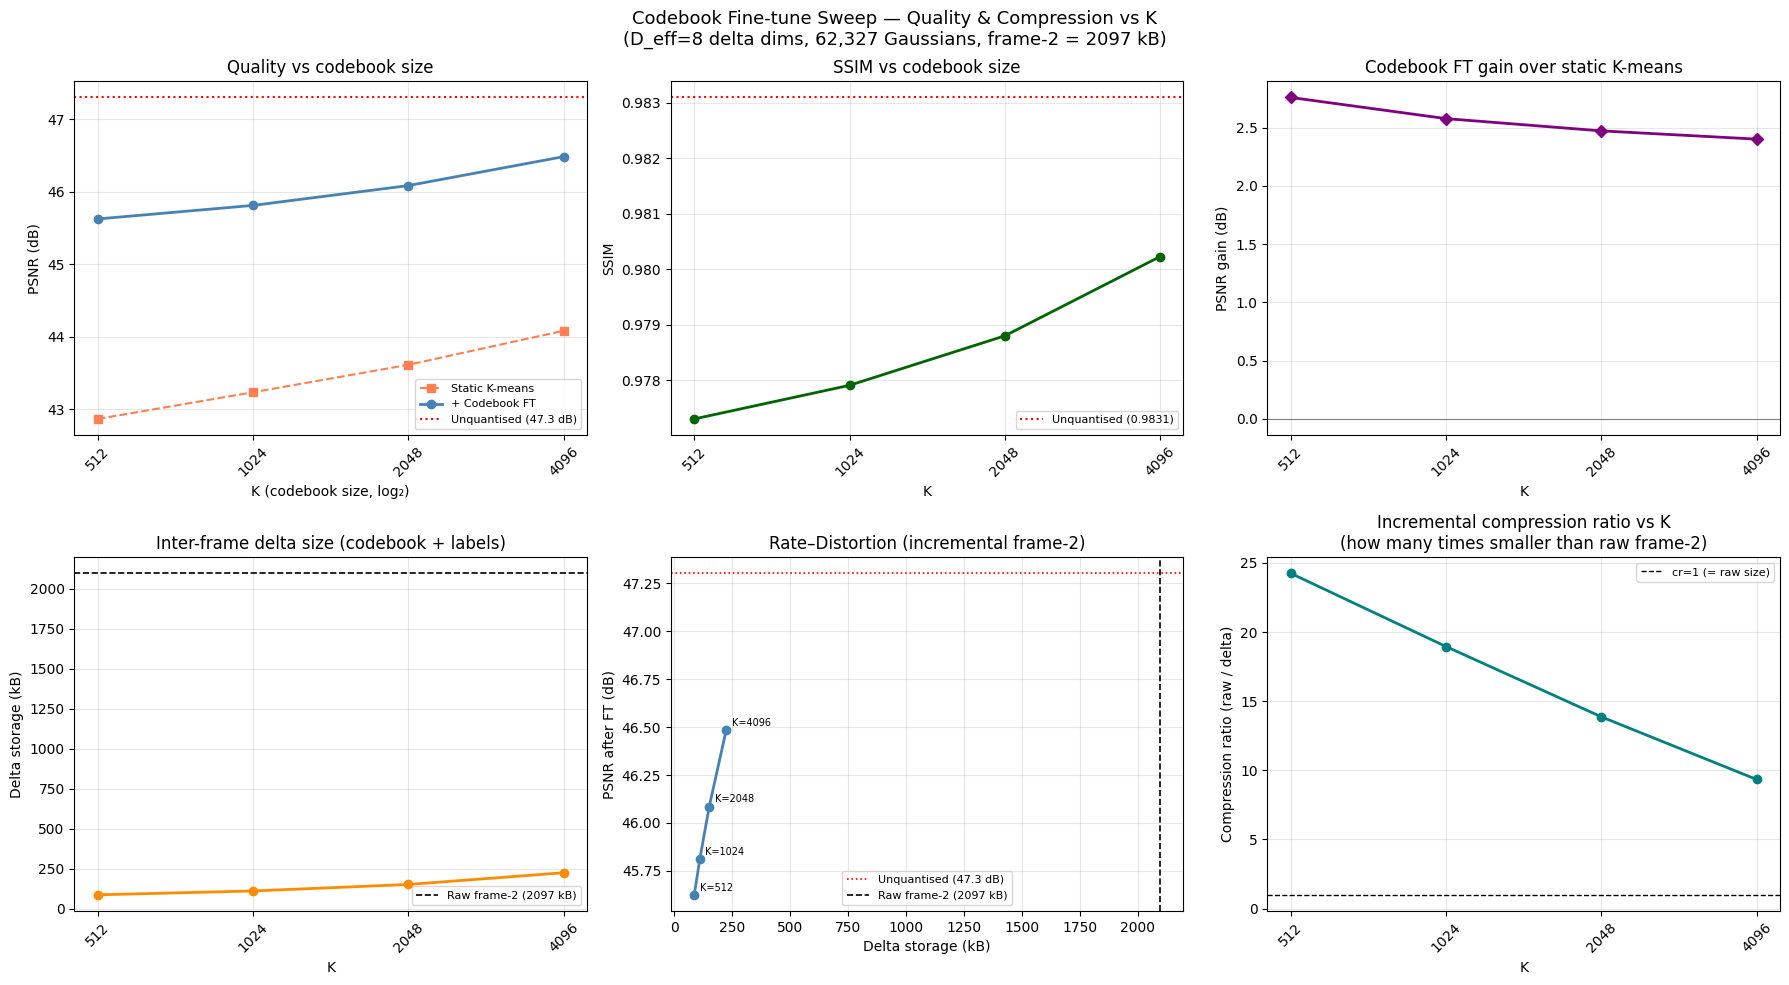

In [34]:
K_SWEEP       = [512, 1024, 2048, 4096]
NUM_ITER_SW   = 2000   # iterations per K (converges in <500, so this is generous)
LR_SW         = 5e-4
LOG_SW        = 500

# ── Storage constants ─────────────────────────────────────────────────────
# Effective delta dimensions after removing always-zero / redundant params:
#   Δmean_z=0, Δscale_z=0, Δquat_x=0, Δquat_y=0  → 4 zeros
#   Δrgb_g = Δrgb_b = Δrgb_r                       → 2 redundant
D_EFF = D - 6          # 14 − 6 = 8 effective delta dims
raw_frame2_bytes = H * W * 2   # int16

# Base (frame-1) with redundancy reduction: 9 effective params/Gaussian
base_eff_bytes = N_G * 9 * 4   # 9 non-redundant params × float32

print(f"Sweep K = {K_SWEEP}")
print(f"D_eff (delta dims after redundancy removal) = {D_EFF}")
print(f"Raw frame-2 size  : {raw_frame2_bytes/1e3:.1f} kB  ({raw_frame2_bytes:,} bytes)")
print(f"Base frame-1 size : {base_eff_bytes/1e6:.2f} MB  ({base_eff_bytes:,} bytes, 9 params/Gaussian)")
print(f"Unquantised ref   : PSNR={ref_psnr:.2f} dB  SSIM={ref_ssim:.4f}")
print("=" * 72)

sweep_results = []   # rows: (K, psnr_static, psnr_ft, ssim_ft, delta_bytes, cr_incr, cr_total)

for k_sw in K_SWEEP:
    # ── K-means ──────────────────────────────────────────────────────────
    km_sw = MiniBatchKMeans(
        n_clusters=k_sw, init='k-means++', n_init=10,
        max_iter=500, batch_size=min(10_000, N_G), random_state=42,
    )
    km_sw.fit(delta_scaled)
    labels_sw   = torch.tensor(km_sw.labels_, dtype=torch.long, device=device)
    centroids_sw = torch.tensor(
        scaler.inverse_transform(km_sw.cluster_centers_),
        dtype=torch.float32, device=device,
    )  # [k_sw, 14]

    # ── Baseline: static centroid quality ────────────────────────────────
    with torch.no_grad():
        d_s0 = centroids_sw[labels_sw]
        rend_s0, _, _ = render(
            base_means      + d_s0[:, S_M],
            base_log_scales + d_s0[:, S_S],
            base_quats      + d_s0[:, S_Q],
            base_rgbs       + d_s0[:, S_R],
            base_opacities  + d_s0[:, S_O],
            viewmat, K, W, H,
        )
    psnr_static = float(-10 * np.log10(
        np.mean((np.clip(rend_s0[:,:,0].cpu().numpy(),0,1) - target2_np)**2) + 1e-10))

    # ── Learnable codebook, initialised from K-means ─────────────────────
    codebook_sw = centroids_sw.clone().requires_grad_(True)
    opt_sw = torch.optim.Adam([codebook_sw], lr=LR_SW)
    scaler_sw = GradScaler(enabled=USE_FP16)

    for it_sw in range(NUM_ITER_SW):
        with autocast(device_type='cuda', dtype=torch.float16, enabled=USE_FP16):
            d_sw = codebook_sw[labels_sw]                    # [N, 14]
            rend_sw, _, _ = render(
                base_means      + d_sw[:, S_M],
                base_log_scales + d_sw[:, S_S],
                base_quats      + d_sw[:, S_Q],
                base_rgbs       + d_sw[:, S_R],
                base_opacities  + d_sw[:, S_O],
                viewmat, K, W, H,
            )
            loss_sw = mse_loss_fn(rend_sw, gt_image2)
        opt_sw.zero_grad()
        scaler_sw.scale(loss_sw).backward()
        scaler_sw.step(opt_sw)
        scaler_sw.update()

    # ── Final quality ────────────────────────────────────────────────────
    with torch.no_grad():
        d_final = codebook_sw[labels_sw]
        rend_final, _, _ = render(
            base_means      + d_final[:, S_M],
            base_log_scales + d_final[:, S_S],
            base_quats      + d_final[:, S_Q],
            base_rgbs       + d_final[:, S_R],
            base_opacities  + d_final[:, S_O],
            viewmat, K, W, H,
        )
    rec_np_sw = np.clip(rend_final[:,:,0].cpu().numpy(), 0, 1)
    psnr_ft = float(-10 * np.log10(np.mean((rec_np_sw - target2_np)**2) + 1e-10))
    ssim_ft = float(ssim(target2_np, rec_np_sw, data_range=1.0))

    # ── Storage (using D_EFF for codebook, since 6 dims are always 0/dup) ─
    bits_idx_sw   = math.ceil(math.log2(max(k_sw, 2)))
    cb_bytes_sw   = k_sw * D_EFF * 4                          # codebook
    lbl_bytes_sw  = math.ceil(N_G * bits_idx_sw / 8)          # labels
    delta_bytes_sw = cb_bytes_sw + lbl_bytes_sw                # incremental frame-2 cost
    total_bytes_sw = base_eff_bytes + delta_bytes_sw           # base + delta

    cr_incr  = raw_frame2_bytes / delta_bytes_sw               # delta vs raw frame-2
    cr_total = raw_frame2_bytes / total_bytes_sw               # (base+delta) vs raw frame-2

    sweep_results.append(dict(
        K=k_sw, psnr_static=psnr_static, psnr_ft=psnr_ft, ssim_ft=ssim_ft,
        cb_bytes=cb_bytes_sw, lbl_bytes=lbl_bytes_sw,
        delta_bytes=delta_bytes_sw, total_bytes=total_bytes_sw,
        cr_incr=cr_incr, cr_total=cr_total,
    ))

    print(f"  K={k_sw:>5d}  static={psnr_static:.2f} dB → FT={psnr_ft:.2f} dB  "
          f"SSIM={ssim_ft:.4f}  |Δ|={delta_bytes_sw/1e3:.1f} kB  "
          f"cr_incr={cr_incr:.2f}×  cr_total={cr_total:.4f}×")

print("\n✅ Sweep complete")

# ── Summary table ─────────────────────────────────────────────────────────
print()
print(f"{'K':>6} {'PSNR_static':>12} {'PSNR_FT':>9} {'ΔPSNR':>7} "
      f"{'SSIM_FT':>8} {'Δ_kB':>8} {'cr_incr':>9} {'cr_total':>10}")
print("-" * 80)
for r in sweep_results:
    gain = r['psnr_ft'] - r['psnr_static']
    print(f"{r['K']:>6d} {r['psnr_static']:>12.2f} {r['psnr_ft']:>9.2f} {gain:>+7.2f} "
          f"{r['ssim_ft']:>8.4f} {r['delta_bytes']/1e3:>8.1f} "
          f"{r['cr_incr']:>9.2f}× {r['cr_total']:>9.5f}×")
print(f"\n  cr_incr  = raw_frame2 / (codebook + labels)   [incremental cost only]")
print(f"  cr_total = raw_frame2 / (base_frame1 + delta)  [full representation cost]")
print(f"  Raw frame-2: {raw_frame2_bytes/1e3:.1f} kB  |  Base frame-1: {base_eff_bytes/1e3:.1f} kB")
print(f"  Unquantised ceiling: PSNR={ref_psnr:.2f} dB")

# ── Plots ─────────────────────────────────────────────────────────────────
Ks       = [r['K']          for r in sweep_results]
psnr_st  = [r['psnr_static'] for r in sweep_results]
psnr_fts = [r['psnr_ft']    for r in sweep_results]
ssim_fts = [r['ssim_ft']    for r in sweep_results]
delta_kb = [r['delta_bytes']/1e3  for r in sweep_results]
cr_incrs = [r['cr_incr']    for r in sweep_results]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1 — PSNR vs K
axes[0,0].semilogx(Ks, psnr_st,  's--', color='coral',     linewidth=1.5, label='Static K-means',   base=2)
axes[0,0].semilogx(Ks, psnr_fts, 'o-',  color='steelblue', linewidth=2,   label='+ Codebook FT',    base=2)
axes[0,0].axhline(ref_psnr, color='red', linestyle=':', linewidth=1.5, label=f'Unquantised ({ref_psnr:.1f} dB)')
axes[0,0].set_xlabel('K (codebook size, log₂)');  axes[0,0].set_ylabel('PSNR (dB)')
axes[0,0].set_title('Quality vs codebook size');  axes[0,0].legend(fontsize=8)
axes[0,0].set_xticks(Ks);  axes[0,0].set_xticklabels([str(k) for k in Ks], rotation=45)
axes[0,0].grid(True, alpha=0.3)

# 2 — SSIM vs K
axes[0,1].semilogx(Ks, ssim_fts, 'o-', color='darkgreen', linewidth=2, base=2)
axes[0,1].axhline(ref_ssim, color='red', linestyle=':', linewidth=1.5, label=f'Unquantised ({ref_ssim:.4f})')
axes[0,1].set_xlabel('K');  axes[0,1].set_ylabel('SSIM')
axes[0,1].set_title('SSIM vs codebook size');  axes[0,1].legend(fontsize=8)
axes[0,1].set_xticks(Ks);  axes[0,1].set_xticklabels([str(k) for k in Ks], rotation=45)
axes[0,1].grid(True, alpha=0.3)

# 3 — FT gain (PSNR_FT − PSNR_static)
gains = [ft - st for ft, st in zip(psnr_fts, psnr_st)]
axes[0,2].semilogx(Ks, gains, 'D-', color='purple', linewidth=2, base=2)
axes[0,2].set_xlabel('K');  axes[0,2].set_ylabel('PSNR gain (dB)')
axes[0,2].set_title('Codebook FT gain over static K-means')
axes[0,2].set_xticks(Ks);  axes[0,2].set_xticklabels([str(k) for k in Ks], rotation=45)
axes[0,2].grid(True, alpha=0.3)
axes[0,2].axhline(0, color='gray', linewidth=0.8)

# 4 — Delta storage kB vs K
axes[1,0].semilogx(Ks, delta_kb, 'o-', color='darkorange', linewidth=2, base=2)
axes[1,0].axhline(raw_frame2_bytes/1e3, color='black', linestyle='--', linewidth=1.2,
                   label=f'Raw frame-2 ({raw_frame2_bytes/1e3:.0f} kB)')
axes[1,0].set_xlabel('K');  axes[1,0].set_ylabel('Delta storage (kB)')
axes[1,0].set_title('Inter-frame delta size (codebook + labels)');  axes[1,0].legend(fontsize=8)
axes[1,0].set_xticks(Ks);  axes[1,0].set_xticklabels([str(k) for k in Ks], rotation=45)
axes[1,0].grid(True, alpha=0.3)

# 5 — Rate-distortion: delta_kB vs PSNR (x=storage, y=quality)
axes[1,1].plot(delta_kb, psnr_fts, 'o-', color='steelblue', linewidth=2)
for r in sweep_results:
    axes[1,1].annotate(f'K={r["K"]}', (r['delta_bytes']/1e3, r['psnr_ft']),
                        textcoords='offset points', xytext=(4, 3), fontsize=7)
axes[1,1].axhline(ref_psnr, color='red', linestyle=':', linewidth=1.2,
                   label=f'Unquantised ({ref_psnr:.1f} dB)')
axes[1,1].axvline(raw_frame2_bytes/1e3, color='black', linestyle='--', linewidth=1.2,
                   label=f'Raw frame-2 ({raw_frame2_bytes/1e3:.0f} kB)')
axes[1,1].set_xlabel('Delta storage (kB)');  axes[1,1].set_ylabel('PSNR after FT (dB)')
axes[1,1].set_title('Rate–Distortion (incremental frame-2)');  axes[1,1].legend(fontsize=8)
axes[1,1].grid(True, alpha=0.3)

# 6 — Incremental compression ratio vs K
axes[1,2].semilogx(Ks, cr_incrs, 'o-', color='teal', linewidth=2, base=2)
axes[1,2].axhline(1.0, color='black', linestyle='--', linewidth=1, label='cr=1 (= raw size)')
axes[1,2].set_xlabel('K');  axes[1,2].set_ylabel('Compression ratio (raw / delta)')
axes[1,2].set_title('Incremental compression ratio vs K\n(how many times smaller than raw frame-2)')
axes[1,2].set_xticks(Ks);  axes[1,2].set_xticklabels([str(k) for k in Ks], rotation=45)
axes[1,2].legend(fontsize=8);  axes[1,2].grid(True, alpha=0.3)

plt.suptitle('Codebook Fine-tune Sweep — Quality & Compression vs K\n'
             f'(D_eff={D_EFF} delta dims, {N_G:,} Gaussians, frame-2 = {raw_frame2_bytes/1e3:.0f} kB)',
             fontsize=13)
plt.tight_layout()
plt.show()
